## regplot

In [1]:
import seaborn as sns  # 导入seaborn库，用于高级数据可视化，提供美观的统计图形
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot模块，用于创建和定制图表
import pandas as pd  # 导入pandas库，用于数据处理和创建DataFrame
import numpy as np  # 导入numpy库，用于数值计算和生成随机数据
from scipy import stats  # 导入scipy.stats模块，用于统计分析和拟合

# 设置中文字体和样式
plt.rcParams['axes.unicode_minus'] = False  # 设置不显示负号为方块，确保负值符号正确显示
sns.set_style("whitegrid")  # 设置seaborn绘图风格为白色网格背景，提升图表可读性
plt.rcParams['font.family'] = ['Times New Roman',
                               'STsong']  # 设置图表字体为Times New Roman和宋体，支持中英文显示
# 准备数据集
# 加载内置数据集
tips = sns.load_dataset('tips')  # 加载seaborn内置的tips数据集，包含餐厅消费数据，用于演示分类和分布
mpg = sns.load_dataset('mpg')  # 加载seaborn内置的mpg数据集，包含汽车燃油效率数据，用于回归分析
diamonds = sns.load_dataset(
    'diamonds')  # 加载seaborn内置的diamonds数据集，包含钻石价格数据，用于多变量分析

# 创建自定义数据集
np.random.seed(42)  # 设置随机种子为42，确保生成的数据可重现
# 线性关系数据
linear_data = pd.DataFrame(
    {  # 创建包含线性关系的数据框，用于展示线性回归
        'x':  # 列名，定义x轴数据
        np.linspace(0, 10, 50),  # 生成0到10的50个均匀分布点，作为x轴值
        'y':  # 列名，定义y轴数据
        2 * np.linspace(0, 10, 50) + np.random.normal(0, 2, 50) + 5  # y=2x+正态噪声+5，模拟带噪声的线性关系
    })

# 非线性关系数据
nonlinear_data = pd.DataFrame(
    {  # 创建包含非线性关系的数据框，用于展示二次函数关系
        'x':  # 列名，定义x轴数据
        np.linspace(0, 10, 50),  # 生成0到10的50个均匀分布点，作为x轴值
        'y':  # 列名，定义y轴数据
        0.5 * (np.linspace(0, 10, 50)**2) + np.random.normal(0, 3, 50)  # y=0.5x^2+正态噪声，模拟带噪声的二次关系
    })

# 有异常值的数据
outlier_data = pd.DataFrame(
    {  # 创建包含异常值的数据框，用于展示异常点对可视化的影响
        'x':  # 列名，定义x轴数据
        np.concatenate([np.random.normal(5, 2, 45), [15, 16, 17, 18, 19]]),  # 45个正态分布点+5个异常点，模拟x轴数据
        'y':  # 列名，定义y轴数据
        np.concatenate([np.random.normal(10, 3, 45), [30, 32, 35, 38, 40]])  # 45个正态分布点+5个异常点，模拟y轴数据
    })

# 逻辑回归数据
logistic_data = pd.DataFrame({  # 创建用于逻辑回归的数据框，展示二分类问题
    'x':  # 列名，定义x轴数据
    np.linspace(-5, 5, 100),  # 生成-5到5的100个均匀分布点，作为x轴值
    'y':  # 列名，定义y轴数据
    (np.random.rand(100) < 1 / (1 + np.exp(-np.linspace(-5, 5, 100)))).astype(int)  # 使用sigmoid函数生成0/1分类，模拟逻辑回归数据
})

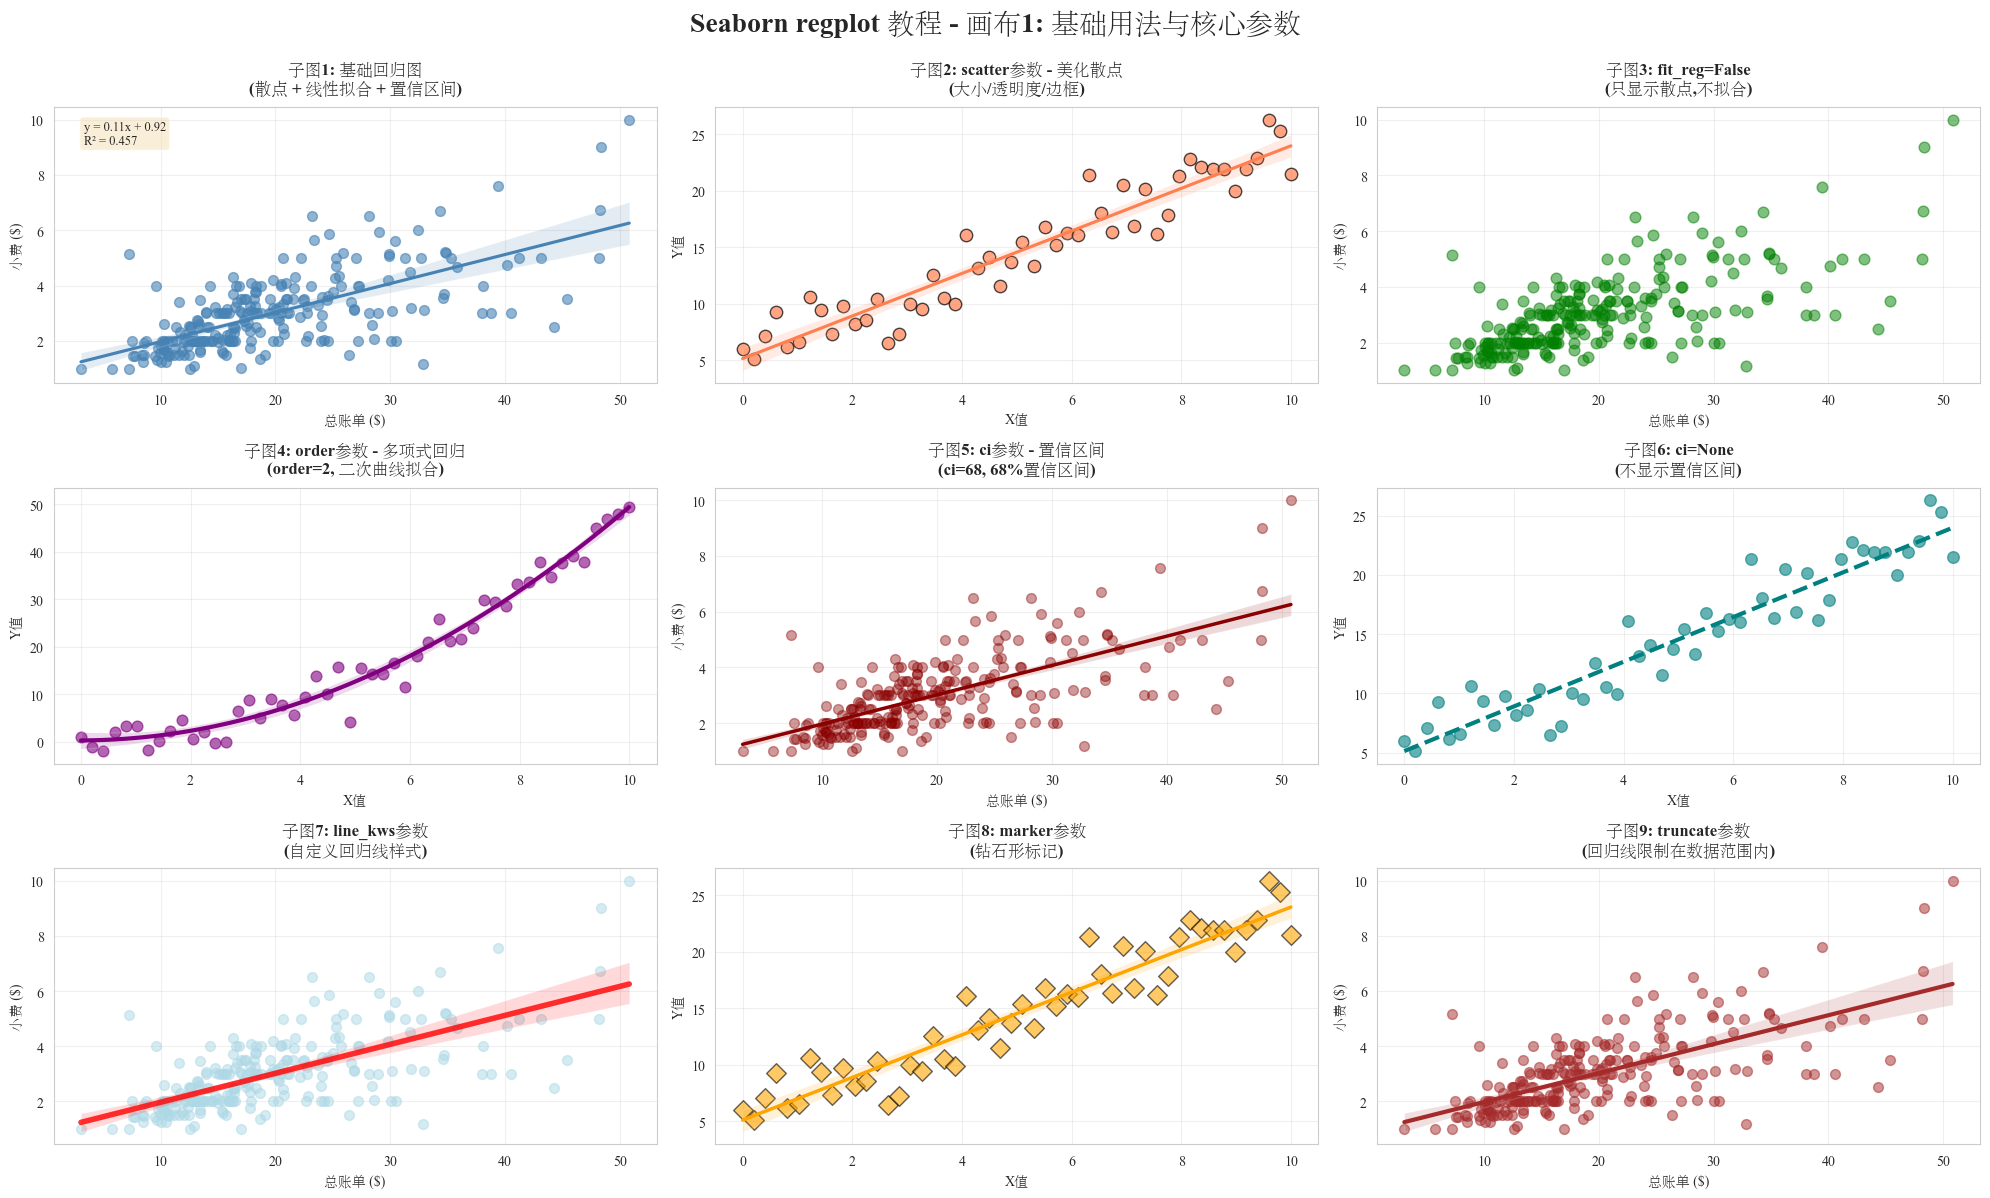

In [2]:
# ==================== 画布 1: 基础用法与核心参数 ====================
fig1 = plt.figure(figsize=(20, 12))  # 创建画布，设置尺寸为20x12英寸，提供足够空间展示9个子图
fig1.suptitle(
    'Seaborn regplot 教程 - 画布1: 基础用法与核心参数',  # 设置画布总标题，说明教程主题
    fontsize=20,  # 设置标题字体大小为20，提升标题醒目性
    fontweight='bold',  # 设置标题为粗体，增强视觉效果
    y=0.995)  # 设置标题垂直位置，靠近画布顶部，避免遮挡子图

# ========== 子图 1：基础回归图 - 最简单的用法 ==========
ax1 = plt.subplot(3, 3, 1)  # 创建3x3网格的第1个子图，用于展示基础回归图
sns.regplot(
    data=tips,  # 使用tips数据集，绘制回归图
    x='total_bill',  # x轴使用'total_bill'列，表示总账单金额
    y='tip',  # y轴使用'tip'列，表示小费金额
    ax=ax1,  # 指定子图对象为ax1，确保绘制在正确位置
    scatter_kws={  # 散点参数字典，控制散点样式
        's': 50,  # 设置散点大小为50，控制点的大小
        'alpha': 0.6  # 设置散点透明度为0.6，增强重叠点的可视性
    },
    color='steelblue')  # 设置散点和回归线颜色为钢蓝色，统一视觉风格
ax1.set_title(
    '子图1: 基础回归图\n(散点 + 线性拟合 + 置信区间)',  # 设置子图标题，说明包含散点、线性拟合和置信区间
    fontsize=12,  # 设置标题字体大小为12，适合子图尺寸
    fontweight='bold',  # 设置标题为粗体，突出显示
    pad=10)  # 设置标题与图表的间距为10，避免重叠
ax1.set_xlabel('总账单 ($)', fontsize=10)  # 设置x轴标签为“总账单 ($)” ，字体大小10
ax1.set_ylabel('小费 ($)', fontsize=10)  # 设置y轴标签为“小费 ($)” ，字体大小10
# 添加回归方程
slope, intercept, r_value, p_value, std_err = stats.linregress(  # 使用scipy.stats.linregress计算线性回归参数
    tips['total_bill'], tips['tip'])  # 输入x和y数据，计算斜率、截距、R值等
ax1.text(
    0.05,  # 在子图坐标系的x=0.05位置添加文本
    0.95,  # 在子图坐标系的y=0.95位置（左上角）
    f'y = {slope:.2f}x + {intercept:.2f}\nR² = {r_value**2:.3f}',  # 显示回归方程和R²值，保留2位和3位小数
    transform=ax1.transAxes,  # 使用子图坐标系（0-1范围），便于定位
    fontsize=9,  # 设置文本字体大小为9，适合子图比例
    verticalalignment='top',  # 文本顶部对齐，避免溢出
    bbox=dict(boxstyle='round', facecolor='wheat',
              alpha=0.5))  # 添加圆角背景框，浅黄色，透明度0.5
ax1.grid(True, alpha=0.3)  # 添加网格线，透明度0.3，增强数据可读性

# ========== 子图 2：scatter参数 - 控制散点显示 ==========
ax2 = plt.subplot(3, 3, 2)  # 创建3x3网格的第2个子图，展示散点参数控制
sns.regplot(
    data=linear_data,  # 使用linear_data数据集，展示线性关系
    x='x',  # x轴使用'x'列，线性分布的数据
    y='y',  # y轴使用'y'列，带噪声的线性数据
    ax=ax2,  # 指定子图对象为ax2
    scatter=True,  # 显式启用散点显示（默认值，强调参数作用）
    color='coral',  # 设置散点和回归线颜色为珊瑚色，温暖视觉效果
    scatter_kws={  # 散点参数字典，精细控制散点样式
        's': 80,  # 设置散点大小为80，较大点便于观察
        'alpha': 0.7,  # 设置散点透明度为0.7，平衡重叠与清晰度
        'edgecolor': 'black',  # 设置散点边框颜色为黑色，增强对比
        'linewidths': 1  # 设置散点边框线宽为1，突出散点轮廓
    })
ax2.set_title(
    '子图2: scatter参数 - 美化散点\n(大小/透明度/边框)',  # 设置标题，说明散点样式控制
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax2.set_xlabel('X值', fontsize=10)  # 设置x轴标签为“X值”，字体大小10
ax2.set_ylabel('Y值', fontsize=10)  # 设置y轴标签为“Y值”，字体大小10
ax2.grid(True, alpha=0.3)  # 添加网格线，透明度0.3，提升可读性

# ========== 子图 3：fit_reg参数 - 只显示散点 ==========
ax3 = plt.subplot(3, 3, 3)  # 创建3x3网格的第3个子图，展示无回归线的散点图
sns.regplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    ax=ax3,  # 指定子图对象为ax3
    fit_reg=False,  # 禁用回归线拟合，仅显示散点
    scatter_kws={  # 散点参数字典
        's': 60,  # 设置散点大小为60，适中显示
        'alpha': 0.5  # 设置散点透明度为0.5，适合观察分布
    },
    color='green')  # 设置散点颜色为绿色，清新视觉效果
ax3.set_title(
    '子图3: fit_reg=False\n(只显示散点,不拟合)',  # 设置标题，说明仅显示散点
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax3.set_xlabel('总账单 ($)', fontsize=10)  # 设置x轴标签，字体大小10
ax3.set_ylabel('小费 ($)', fontsize=10)  # 设置y轴标签，字体大小10
ax3.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 4：order参数 - 多项式回归 ==========
ax4 = plt.subplot(3, 3, 4)  # 创建3x3网格的第4个子图，展示多项式回归
# 二次多项式拟合
sns.regplot(
    data=nonlinear_data,  # 使用nonlinear_data数据集，展示非线性关系
    x='x',  # x轴使用'x'列
    y='y',  # y轴使用'y'列，二次关系数据
    ax=ax4,  # 指定子图对象为ax4
    order=2,  # 设置回归为二次多项式，拟合二次曲线
    scatter_kws={  # 散点参数字典
        's': 60,  # 设置散点大小为60
        'alpha': 0.6  # 设置散点透明度为0.6
    },
    color='purple',  # 设置散点和回归线颜色为紫色，突出曲线
    line_kws={'linewidth': 3})  # 设置回归线宽为3，强调拟合曲线
ax4.set_title(
    '子图4: order参数 - 多项式回归\n(order=2, 二次曲线拟合)',  # 设置标题，说明二次多项式拟合
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax4.set_xlabel('X值', fontsize=10)  # 设置x轴标签，字体大小10
ax4.set_ylabel('Y值', fontsize=10)  # 设置y轴标签，字体大小10
ax4.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 5：ci参数 - 置信区间控制 ==========
ax5 = plt.subplot(3, 3, 5)  # 创建3x3网格的第5个子图，展示置信区间控制
# 显示不同置信区间
sns.regplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    ax=ax5,  # 指定子图对象为ax5
    ci=68,  # 设置置信区间为68%，显示较窄的置信带
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50
        'alpha': 0.4  # 设置散点透明度为0.4，突出置信带
    },
    color='darkred',  # 设置散点和回归线颜色为暗红色，醒目效果
    line_kws={'linewidth': 2.5})  # 设置回归线宽为2.5，适中显示
ax5.set_title(
    '子图5: ci参数 - 置信区间\n(ci=68, 68%置信区间)',  # 设置标题，说明置信区间设置
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax5.set_xlabel('总账单 ($)', fontsize=10)  # 设置x轴标签，字体大小10
ax5.set_ylabel('小费 ($)', fontsize=10)  # 设置y轴标签，字体大小10
ax5.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 6：ci=None - 不显示置信区间 ==========
ax6 = plt.subplot(3, 3, 6)  # 创建3x3网格的第6个子图，展示无置信区间
sns.regplot(
    data=linear_data,  # 使用linear_data数据集
    x='x',  # x轴使用'x'列
    y='y',  # y轴使用'y'列
    ax=ax6,  # 指定子图对象为ax6
    ci=None,  # 禁用置信区间显示，仅显示回归线和散点
    scatter_kws={  # 散点参数字典
        's': 70,  # 设置散点大小为70
        'alpha': 0.6  # 设置散点透明度为0.6
    },
    color='teal',  # 设置散点和回归线颜色为青色，清新风格
    line_kws={  # 回归线参数字典
        'linewidth': 3,  # 设置回归线宽为3，突出线条
        'linestyle': '--'  # 设置回归线为虚线，增加样式变化
    })
ax6.set_title(
    '子图6: ci=None\n(不显示置信区间)',  # 设置标题，说明无置信区间
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax6.set_xlabel('X值', fontsize=10)  # 设置x轴标签，字体大小10
ax6.set_ylabel('Y值', fontsize=10)  # 设置y轴标签，字体大小10
ax6.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 7：line_kws参数 - 自定义回归线 ==========
ax7 = plt.subplot(3, 3, 7)  # 创建3x3网格的第7个子图，展示回归线样式控制
sns.regplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    ax=ax7,  # 指定子图对象为ax7
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50
        'alpha': 0.5,  # 设置散点透明度为0.5
        'color': 'lightblue'  # 设置散点颜色为浅蓝色，与回归线区分
    },
    line_kws={  # 回归线参数字典
        'color': 'red',  # 设置回归线颜色为红色，突出线条
        'linewidth': 4,  # 设置回归线宽为4，强调线条
        'linestyle': '-',  # 设置回归线为实线，经典样式
        'alpha': 0.8  # 设置回归线透明度为0.8，增强可见性
    })
ax7.set_title(
    '子图7: line_kws参数\n(自定义回归线样式)',  # 设置标题，说明回归线样式控制
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax7.set_xlabel('总账单 ($)', fontsize=10)  # 设置x轴标签，字体大小10
ax7.set_ylabel('小费 ($)', fontsize=10)  # 设置y轴标签，字体大小10
ax7.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 8：marker参数 - 不同标记样式 ==========
ax8 = plt.subplot(3, 3, 8)  # 创建3x3网格的第8个子图，展示不同散点标记
sns.regplot(
    data=linear_data,  # 使用linear_data数据集
    x='x',  # x轴使用'x'列
    y='y',  # y轴使用'y'列
    ax=ax8,  # 指定子图对象为ax8
    marker='D',  # 设置散点标记为钻石形（D），增加样式多样性
    scatter_kws={  # 散点参数字典
        's': 100,  # 设置散点大小为100，较大点突出标记形状
        'alpha': 0.6,  # 设置散点透明度为0.6
        'edgecolor': 'black'  # 设置散点边框为黑色，增强对比
    },
    color='orange',  # 设置散点和回归线颜色为橙色，温暖风格
    line_kws={'linewidth': 2.5})  # 设置回归线宽为2.5，适中显示
ax8.set_title(
    '子图8: marker参数\n(钻石形标记)',  # 设置标题，说明使用钻石形标记
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax8.set_xlabel('X值', fontsize=10)  # 设置x轴标签，字体大小10
ax8.set_ylabel('Y值', fontsize=10)  # 设置y轴标签，字体大小10
ax8.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 9：truncate参数 - 截断回归线 ==========
ax9 = plt.subplot(3, 3, 9)  # 创建3x3网格的第9个子图，展示回归线截断
sns.regplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    ax=ax9,  # 指定子图对象为ax9
    truncate=True,  # 限制回归线在数据范围内，不延伸到画布边界
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50
        'alpha': 0.5  # 设置散点透明度为0.5
    },
    color='brown',  # 设置散点和回归线颜色为棕色，沉稳风格
    line_kws={'linewidth': 3})  # 设置回归线宽为3，突出线条
ax9.set_title(
    '子图9: truncate参数\n(回归线限制在数据范围内)',  # 设置标题，说明回归线截断效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax9.set_xlabel('总账单 ($)', fontsize=10)  # 设置x轴标签，字体大小10
ax9.set_ylabel('小费 ($)', fontsize=10)  # 设置y轴标签，字体大小10
ax9.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

plt.tight_layout()  # 自动调整子图间距，优化布局，避免重叠
plt.show()  # 显示整个画布，渲染所有子图

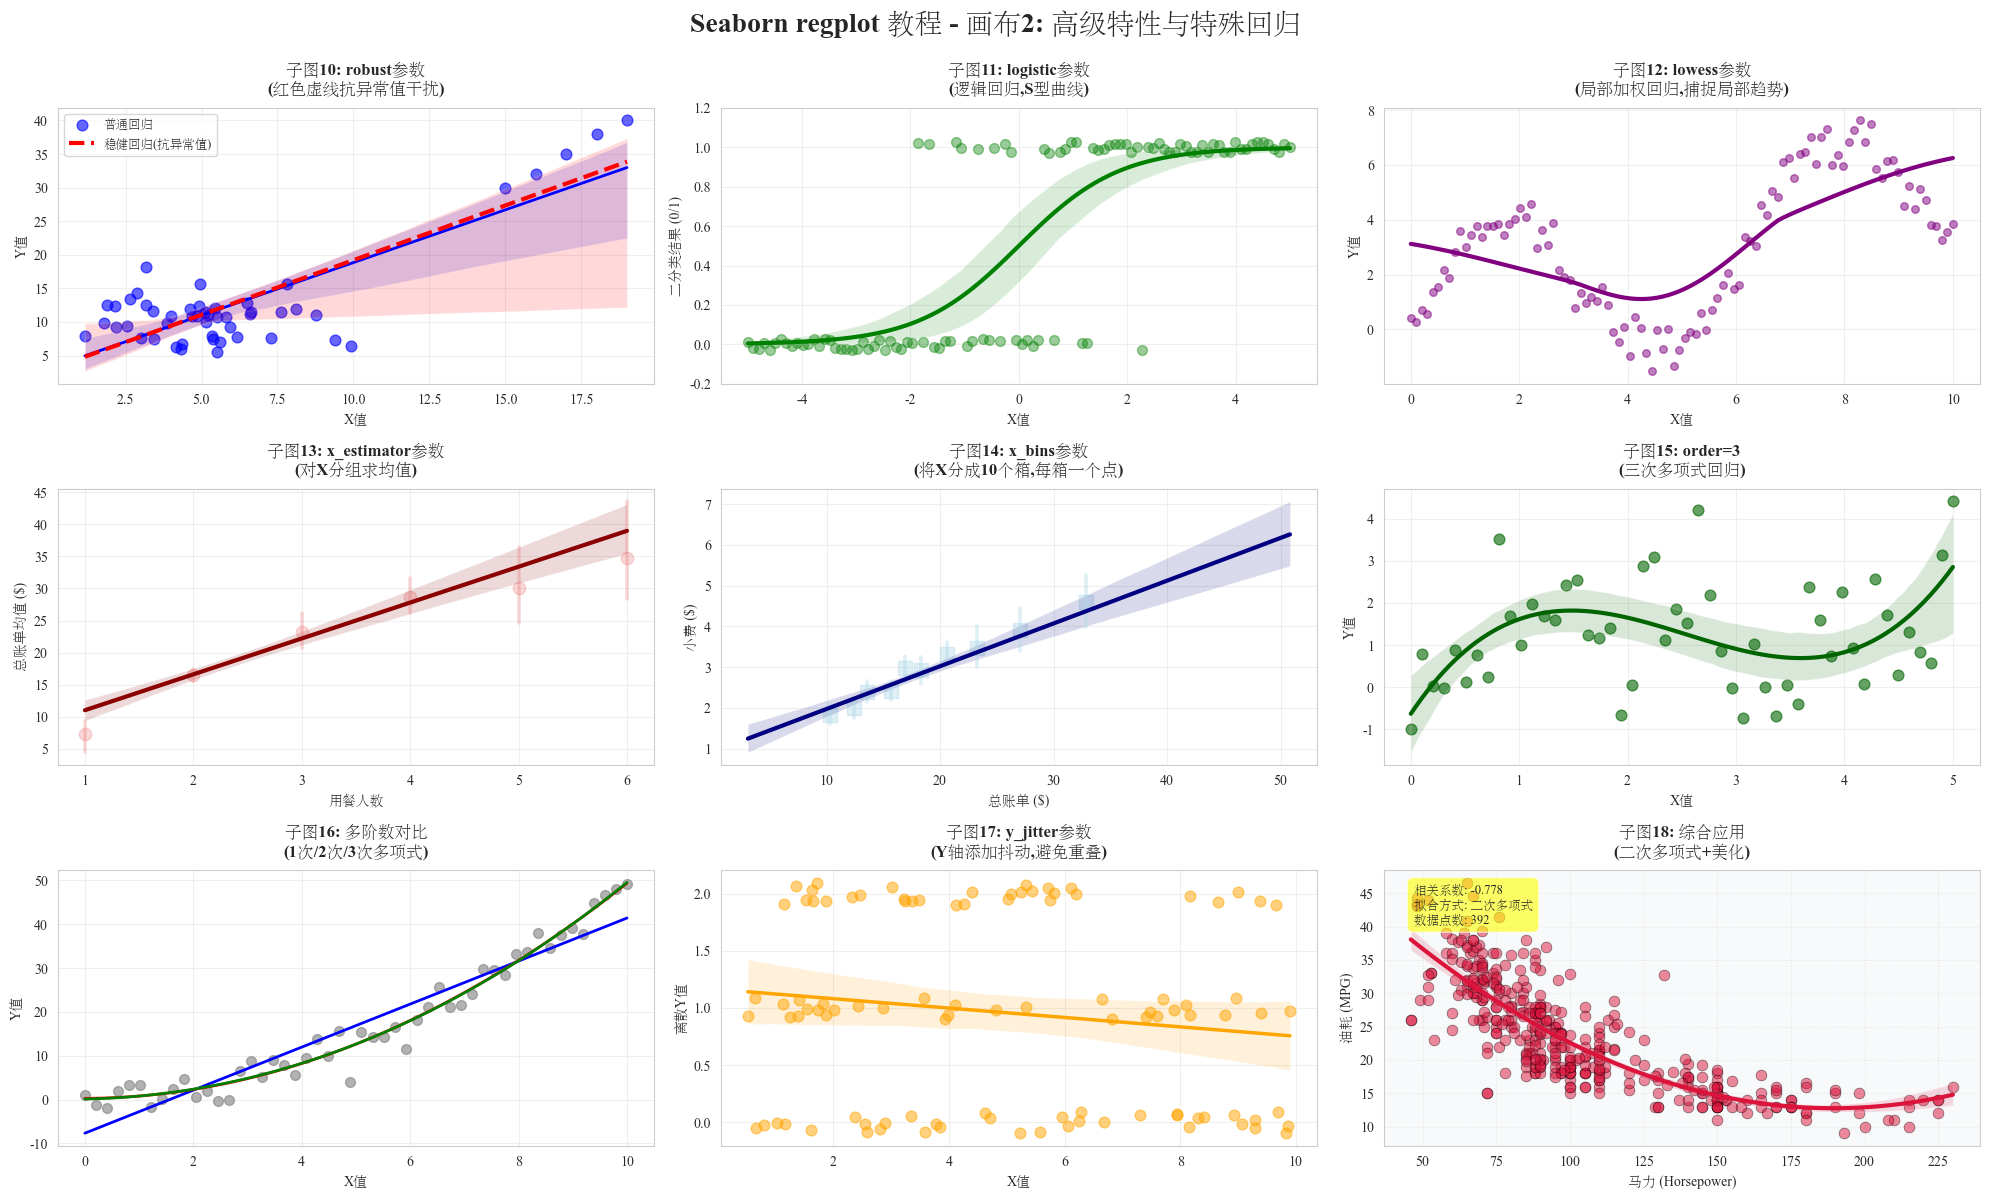

In [3]:
# ==================== 画布 2: 高级特性与特殊回归 ====================
fig2 = plt.figure(figsize=(20, 12))  # 创建画布，尺寸20x12英寸，适合展示9个子图
fig2.suptitle(
    'Seaborn regplot 教程 - 画布2: 高级特性与特殊回归',  # 设置画布总标题，说明高级回归主题
    fontsize=20,  # 标题字体大小20，醒目显示
    fontweight='bold',  # 标题粗体，增强视觉效果
    y=0.995)  # 标题靠近画布顶部，避免遮挡子图

# ========== 子图 10：robust参数 - 稳健回归(抗异常值) ==========
ax10 = plt.subplot(3, 3, 1)  # 创建3x3网格的第1个子图，展示稳健回归
# 普通回归
sns.regplot(
    data=outlier_data,  # 使用outlier_data数据集，包含异常点
    x='x',  # x轴使用'x'列，含异常点的数据
    y='y',  # y轴使用'y'列，含异常点的数据
    ax=ax10,  # 指定子图对象为ax10
    robust=False,  # 禁用稳健回归，使用普通最小二乘法
    scatter_kws={  # 散点参数字典
        's': 60,  # 设置散点大小为60，适中显示
        'alpha': 0.6  # 设置散点透明度为0.6，增强重叠点可见性
    },
    color='blue',  # 设置散点和回归线颜色为蓝色，表示普通回归
    label='普通回归',  # 设置图例标签，标记普通回归线
    line_kws={'linewidth': 2})  # 设置回归线宽为2，适中显示
# 稳健回归
sns.regplot(
    data=outlier_data,  # 再次使用outlier_data数据集
    x='x',  # x轴使用'x'列
    y='y',  # y轴使用'y'列
    ax=ax10,  # 指定子图对象为ax10，叠加在同一子图
    robust=True,  # 启用稳健回归，减少异常点影响
    scatter=False,  # 禁用散点显示，仅显示回归线
    color='red',  # 设置回归线颜色为红色，表示稳健回归
    label='稳健回归(抗异常值)',  # 设置图例标签，标记稳健回归线
    line_kws={  # 回归线参数字典
        'linewidth': 3,  # 设置回归线宽为3，突出线条
        'linestyle': '--'  # 设置回归线为虚线，区分普通回归
    })
ax10.set_title(
    '子图10: robust参数\n(红色虚线抗异常值干扰)',  # 设置标题，说明稳健回归效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax10.set_xlabel('X值', fontsize=10)  # 设置x轴标签，字体大小10
ax10.set_ylabel('Y值', fontsize=10)  # 设置y轴标签，字体大小10
ax10.legend(fontsize=9)  # 显示图例，字体大小9，区分两种回归线
ax10.grid(True, alpha=0.3)  # 添加网格线，透明度0.3，提升可读性

# ========== 子图 11：logistic参数 - 逻辑回归 ==========
ax11 = plt.subplot(3, 3, 2)  # 创建3x3网格的第2个子图，展示逻辑回归
sns.regplot(
    data=logistic_data,  # 使用logistic_data数据集，包含二分类数据
    x='x',  # x轴使用'x'列，连续值
    y='y',  # y轴使用'y'列，0/1二分类值
    ax=ax11,  # 指定子图对象为ax11
    logistic=True,  # 启用逻辑回归，拟合S型曲线
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50，适中显示
        'alpha': 0.4  # 设置散点透明度为0.4，突出S型曲线
    },
    color='green',  # 设置散点和回归线颜色为绿色，清新风格
    line_kws={'linewidth': 3},  # 设置回归线宽为3，突出S型曲线
    y_jitter=0.03)  # 为y值添加0.03的抖动，避免0/1重叠
ax11.set_title(
    '子图11: logistic参数\n(逻辑回归,S型曲线)',  # 设置标题，说明逻辑回归和S型曲线
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax11.set_xlabel('X值', fontsize=10)  # 设置x轴标签，字体大小10
ax11.set_ylabel('二分类结果 (0/1)', fontsize=10)  # 设置y轴标签，说明二分类输出
ax11.set_ylim(-0.2, 1.2)  # 设置y轴范围为-0.2到1.2，完整显示0/1点
ax11.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 12：lowess参数 - 局部加权回归 ==========
ax12 = plt.subplot(3, 3, 3)  # 创建3x3网格的第3个子图，展示局部加权回归
# 创建有局部趋势的数据
x_lowess = np.linspace(0, 10, 100)  # 生成0到10的100个均匀分布点，作为x轴值
y_lowess = np.sin(x_lowess) * 3 + x_lowess * 0.5 + np.random.normal(
    0, 0.5, 100)  # 生成y值：正弦函数+线性趋势+噪声
lowess_data = pd.DataFrame({'x': x_lowess, 'y': y_lowess})  # 创建数据框，存储x和y数据
sns.regplot(
    data=lowess_data,  # 使用lowess_data数据集
    x='x',  # x轴使用'x'列
    y='y',  # y轴使用'y'列，含局部趋势
    ax=ax12,  # 指定子图对象为ax12
    lowess=True,  # 启用局部加权回归（LOWESS），捕捉局部趋势
    scatter_kws={  # 散点参数字典
        's': 30,  # 设置散点大小为30，较小点突出曲线
        'alpha': 0.5  # 设置散点透明度为0.5，平衡显示
    },
    color='purple',  # 设置散点和回归线颜色为紫色，突出曲线
    line_kws={'linewidth': 3})  # 设置回归线宽为3，强调局部趋势
ax12.set_title(
    '子图12: lowess参数\n(局部加权回归,捕捉局部趋势)',  # 设置标题，说明LOWESS回归
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax12.set_xlabel('X值', fontsize=10)  # 设置x轴标签，字体大小10
ax12.set_ylabel('Y值', fontsize=10)  # 设置y轴标签，字体大小10
ax12.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 13：x_estimator参数 - X值聚合 ==========
ax13 = plt.subplot(3, 3, 4)  # 创建3x3网格的第4个子图，展示x值聚合
sns.regplot(
    data=tips,  # 使用tips数据集
    x='size',  # x轴使用'size'列，表示用餐人数（离散值）
    y='total_bill',  # y轴使用'total_bill'列，表示总账单
    ax=ax13,  # 指定子图对象为ax13
    x_estimator=np.mean,  # 对x的每个唯一值计算y的均值，聚合数据
    scatter_kws={  # 散点参数字典
        's': 80,  # 设置散点大小为80，突出均值点
        'alpha': 0.3,  # 设置散点透明度为0.3，降低重叠干扰
        'color': 'lightcoral'  # 设置散点颜色为浅珊瑚色，柔和风格
    },
    line_kws={  # 回归线参数字典
        'color': 'darkred',  # 设置回归线颜色为暗红色，突出线条
        'linewidth': 3  # 设置回归线宽为3，增强可见性
    },
    marker='o',  # 设置散点标记为圆形，经典样式
    color='darkred')  # 设置回归线颜色为暗红色，与line_kws一致
ax13.set_title(
    '子图13: x_estimator参数\n(对X分组求均值)',  # 设置标题，说明x值聚合效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax13.set_xlabel('用餐人数', fontsize=10)  # 设置x轴标签，字体大小10
ax13.set_ylabel('总账单均值 ($)', fontsize=10)  # 设置y轴标签，说明y轴为均值
ax13.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 14：x_bins参数 - X值分箱 ==========
ax14 = plt.subplot(3, 3, 5)  # 创建3x3网格的第5个子图，展示x值分箱
sns.regplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴使用'total_bill'列，连续值
    y='tip',  # y轴使用'tip'列
    ax=ax14,  # 指定子图对象为ax14
    x_bins=10,  # 将x轴分为10个等宽区间，每区间显示一个点
    scatter_kws={  # 散点参数字典
        's': 100,  # 设置散点大小为100，突出分箱点
        'alpha': 0.4,  # 设置散点透明度为0.4，平衡显示
        'color': 'lightblue'  # 设置散点颜色为浅蓝色，柔和风格
    },
    line_kws={  # 回归线参数字典
        'color': 'navy',  # 设置回归线颜色为海军蓝，突出线条
        'linewidth': 3  # 设置回归线宽为3，增强可见性
    },
    marker='s',  # 设置散点标记为方形，区分样式
    color='navy')  # 设置回归线颜色为海军蓝，与line_kws一致
ax14.set_title(
    '子图14: x_bins参数\n(将X分成10个箱,每箱一个点)',  # 设置标题，说明分箱效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax14.set_xlabel('总账单 ($)', fontsize=10)  # 设置x轴标签，字体大小10
ax14.set_ylabel('小费 ($)', fontsize=10)  # 设置y轴标签，字体大小10
ax14.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 15：高阶多项式 - order=3 ==========
ax15 = plt.subplot(3, 3, 6)  # 创建3x3网格的第6个子图，展示三次多项式回归
# 创建三次曲线数据
x_cubic = np.linspace(0, 5, 50)  # 生成0到5的50个均匀分布点，作为x轴值
y_cubic = 0.2 * (x_cubic**3) - 1.5 * (
    x_cubic**2) + 3 * x_cubic + np.random.normal(0, 1, 50)  # 生成y值：三次多项式+噪声
cubic_data = pd.DataFrame({'x': x_cubic, 'y': y_cubic})  # 创建数据框，存储x和y数据
sns.regplot(
    data=cubic_data,  # 使用cubic_data数据集
    x='x',  # x轴使用'x'列
    y='y',  # y轴使用'y'列，含三次趋势
    ax=ax15,  # 指定子图对象为ax15
    order=3,  # 设置回归为三次多项式，拟合三次曲线
    scatter_kws={  # 散点参数字典
        's': 60,  # 设置散点大小为60，适中显示
        'alpha': 0.6  # 设置散点透明度为0.6
    },
    color='darkgreen',  # 设置散点和回归线颜色为暗绿色，沉稳风格
    line_kws={'linewidth': 3})  # 设置回归线宽为3，突出曲线
ax15.set_title(
    '子图15: order=3\n(三次多项式回归)',  # 设置标题，说明三次多项式拟合
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax15.set_xlabel('X值', fontsize=10)  # 设置x轴标签，字体大小10
ax15.set_ylabel('Y值', fontsize=10)  # 设置y轴标签，字体大小10
ax15.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 16：对比不同阶数 ==========
ax16 = plt.subplot(3, 3, 7)  # 创建3x3网格的第7个子图，展示不同阶数多项式对比
# 只显示散点
sns.regplot(
    data=nonlinear_data,  # 使用nonlinear_data数据集
    x='x',  # x轴使用'x'列
    y='y',  # y轴使用'y'列，含二次趋势
    ax=ax16,  # 指定子图对象为ax16
    fit_reg=False,  # 禁用回归线，仅显示散点
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50
        'alpha': 0.6,  # 设置散点透明度为0.6
        'color': 'gray'  # 设置散点颜色为灰色，避免干扰回归线
    })
# 一次
sns.regplot(
    data=nonlinear_data,  # 使用nonlinear_data数据集
    x='x',  # x轴使用'x'列
    y='y',  # y轴使用'y'列
    ax=ax16,  # 指定子图对象为ax16，叠加回归线
    order=1,  # 设置回归为一次多项式（线性）
    scatter=False,  # 禁用散点显示，仅显示回归线
    color='blue',  # 设置回归线颜色为蓝色
    line_kws={  # 回归线参数字典
        'linewidth': 2,  # 设置回归线宽为2，适中显示
        'label': 'order=1'  # 设置图例标签，标记一次回归
    },
    ci=None)  # 禁用置信区间，简化图形
# 二次
sns.regplot(
    data=nonlinear_data,  # 使用nonlinear_data数据集
    x='x',  # x轴使用'x'列
    y='y',  # y轴使用'y'列
    ax=ax16,  # 指定子图对象为ax16，叠加回归线
    order=2,  # 设置回归为二次多项式
    scatter=False,  # 禁用散点显示，仅显示回归线
    color='red',  # 设置回归线颜色为红色
    line_kws={  # 回归线参数字典
        'linewidth': 2,  # 设置回归线宽为2
        'label': 'order=2'  # 设置图例标签，标记二次回归
    },
    ci=None)  # 禁用置信区间
# 三次
sns.regplot(
    data=nonlinear_data,  # 使用nonlinear_data数据集
    x='x',  # x轴使用'x'列
    y='y',  # y轴使用'y'列
    ax=ax16,  # 指定子图对象为ax16，叠加回归线
    order=3,  # 设置回归为三次多项式
    scatter=False,  # 禁用散点显示，仅显示回归线
    color='green',  # 设置回归线颜色为绿色
    line_kws={  # 回归线参数字典
        'linewidth': 2,  # 设置回归线宽为2
        'label': 'order=3'  # 设置图例标签，标记三次回归
    },
    ci=None)  # 禁用置信区间
ax16.set_title(
    '子图16: 多阶数对比\n(1次/2次/3次多项式)',  # 设置标题，说明不同阶数对比
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax16.set_xlabel('X值', fontsize=10)  # 设置x轴标签，字体大小10
ax16.set_ylabel('Y值', fontsize=10)  # 设置y轴标签，字体大小10
# ax16.legend(fontsize=9)  # 图例代码被注释，当前不显示图例
ax16.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 17：y_jitter参数 - Y轴抖动 ==========
ax17 = plt.subplot(3, 3, 8)  # 创建3x3网格的第8个子图，展示y轴抖动
# 创建离散Y值数据
discrete_y = pd.DataFrame({  # 创建数据框，包含随机x值和离散y值
    'x': np.random.rand(100) * 10,  # 生成100个0到10的随机x值
    'y': np.random.choice([0, 1, 2], 100)  # 随机选择0、1、2作为y值，模拟离散数据
})
sns.regplot(
    data=discrete_y,  # 使用discrete_y数据集
    x='x',  # x轴使用'x'列，连续值
    y='y',  # y轴使用'y'列，离散值
    ax=ax17,  # 指定子图对象为ax17
    y_jitter=0.1,  # 为y值添加0.1的抖动，避免离散点重叠
    scatter_kws={  # 散点参数字典
        's': 60,  # 设置散点大小为60
        'alpha': 0.5  # 设置散点透明度为0.5
    },
    color='orange',  # 设置散点和回归线颜色为橙色，温暖风格
    line_kws={'linewidth': 2.5})  # 设置回归线宽为2.5，适中显示
ax17.set_title(
    '子图17: y_jitter参数\n(Y轴添加抖动,避免重叠)',  # 设置标题，说明y轴抖动效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax17.set_xlabel('X值', fontsize=10)  # 设置x轴标签，字体大小10
ax17.set_ylabel('离散Y值', fontsize=10)  # 设置y轴标签，说明y为离散值
ax17.grid(True, alpha=0.3)  # 添加网格线，透明度0.3

# ========== 子图 18：综合应用 - 专业分析图 ==========
ax18 = plt.subplot(3, 3, 9)  # 创建3x3网格的第9个子图，展示综合应用
# 使用mpg数据集
mpg_clean = mpg.dropna(subset=['horsepower',
                               'mpg'])  # 移除horsepower和mpg列中的缺失值，确保数据完整
sns.regplot(
    data=mpg_clean,  # 使用清理后的mpg数据集
    x='horsepower',  # x轴使用'horsepower'列，表示马力
    y='mpg',  # y轴使用'mpg'列，表示油耗
    ax=ax18,  # 指定子图对象为ax18
    order=2,  # 设置回归为二次多项式，拟合非线性关系
    scatter_kws={  # 散点参数字典
        's': 60,  # 设置散点大小为60
        'alpha': 0.5,  # 设置散点透明度为0.5
        'edgecolor': 'black',  # 设置散点边框为黑色，增强对比
        'linewidths': 0.5  # 设置散点边框线宽为0.5，细腻显示
    },
    color='crimson',  # 设置散点和回归线颜色为深红色，醒目风格
    line_kws={'linewidth': 3})  # 设置回归线宽为3，突出曲线
# 添加统计信息
corr = mpg_clean['horsepower'].corr(mpg_clean['mpg'])  # 计算马力和油耗的相关系数
ax18.text(
    0.05,  # 在子图坐标系的x=0.05位置添加文本
    0.95,  # 在子图坐标系的y=0.95位置（左上角）
    f'相关系数: {corr:.3f}\n拟合方式: 二次多项式\n数据点数: {len(mpg_clean)}',  # 显示相关系数、拟合方式和数据点数
    transform=ax18.transAxes,  # 使用子图坐标系（0-1范围），便于定位
    fontsize=9,  # 设置文本字体大小为9，适合子图比例
    verticalalignment='top',  # 文本顶部对齐，避免溢出
    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow',
              alpha=0.6))  # 添加圆角背景框，黄色，透明度0.6
ax18.set_title(
    '子图18: 综合应用\n(二次多项式+美化)',  # 设置标题，说明综合应用
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax18.set_xlabel('马力 (Horsepower)', fontsize=10)  # 设置x轴标签，字体大小10
ax18.set_ylabel('油耗 (MPG)', fontsize=10)  # 设置y轴标签，字体大小10
ax18.grid(True, alpha=0.4, linestyle=':')  # 添加网格线，透明度0.4，虚线样式
ax18.set_facecolor('#f8f9fa')  # 设置子图背景色为浅灰色，提升美观度

plt.tight_layout()  # 自动调整子图间距，优化布局，避免重叠
plt.show()  # 显示整个画布，渲染所有子图

In [4]:
print("=" * 70)
print("📊 Seaborn regplot 教程完成!")
print("=" * 70)
print("\n✅ 画布1覆盖内容:")
print("  • 基础回归图: 散点 + 线性拟合 + 置信区间")
print("  • scatter参数: 控制散点显示与美化")
print("  • fit_reg参数: 控制是否显示回归线")
print("  • order参数: 多项式回归(1次/2次/3次)")
print("  • ci参数: 置信区间控制(68%/95%/None)")
print("  • line_kws参数: 自定义回归线样式")
print("  • marker参数: 不同标记样式")
print("  • truncate参数: 回归线范围控制")
print("\n✅ 画布2覆盖内容:")
print("  • robust参数: 稳健回归,抵抗异常值")
print("  • logistic参数: 逻辑回归,S型曲线")
print("  • lowess参数: 局部加权回归,捕捉局部趋势")
print("  • x_estimator参数: X值聚合(求均值等)")
print("  • x_bins参数: X值分箱处理")
print("  • 高阶多项式: order=3三次回归")
print("  • 多阶数对比: 1次/2次/3次可视化对比")
print("  • y_jitter参数: Y轴抖动避免重叠")
print("  • 综合应用: 多参数组合专业分析")
print("\n" + "=" * 70)
print("💡 学习要点:")
print("  1. 线性关系用 order=1(默认)")
print("  2. 曲线关系用 order=2或3")
print("  3. 有异常值用 robust=True")
print("  4. 二分类用 logistic=True")
print("  5. 局部趋势用 lowess=True")
print("  6. 调整置信区间用 ci 参数")
print("  7. 美化散点用 scatter_kws")
print("  8. 美化回归线用 line_kws")
print("=" * 70)

📊 Seaborn regplot 教程完成!

✅ 画布1覆盖内容:
  • 基础回归图: 散点 + 线性拟合 + 置信区间
  • scatter参数: 控制散点显示与美化
  • fit_reg参数: 控制是否显示回归线
  • order参数: 多项式回归(1次/2次/3次)
  • ci参数: 置信区间控制(68%/95%/None)
  • line_kws参数: 自定义回归线样式
  • marker参数: 不同标记样式
  • truncate参数: 回归线范围控制

✅ 画布2覆盖内容:
  • robust参数: 稳健回归,抵抗异常值
  • logistic参数: 逻辑回归,S型曲线
  • lowess参数: 局部加权回归,捕捉局部趋势
  • x_estimator参数: X值聚合(求均值等)
  • x_bins参数: X值分箱处理
  • 高阶多项式: order=3三次回归
  • 多阶数对比: 1次/2次/3次可视化对比
  • y_jitter参数: Y轴抖动避免重叠
  • 综合应用: 多参数组合专业分析

💡 学习要点:
  1. 线性关系用 order=1(默认)
  2. 曲线关系用 order=2或3
  3. 有异常值用 robust=True
  4. 二分类用 logistic=True
  5. 局部趋势用 lowess=True
  6. 调整置信区间用 ci 参数
  7. 美化散点用 scatter_kws
  8. 美化回归线用 line_kws


## lmplot

In [5]:
import seaborn as sns  # 导入seaborn库，用于高级数据可视化，提供美观的统计图形
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot模块，用于创建和定制图表
import pandas as pd  # 导入pandas库，用于数据处理和创建DataFrame
import numpy as np  # 导入numpy库，用于数值计算和生成随机数据
from scipy import stats  # 导入scipy.stats模块，用于统计分析和拟合

# 设置中文字体和样式
plt.rcParams['axes.unicode_minus'] = False  # 设置不显示负号为方块，确保负值符号正确显示
sns.set_style("whitegrid")  # 设置seaborn绘图风格为白色网格背景，提升图表可读性
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans'
                                   ]  # 设置图表字体为SimHei（支持中文）和DejaVu Sans（备选字体）
# 准备数据集
tips = sns.load_dataset('tips')  # 加载seaborn内置的tips数据集，包含餐厅消费数据，用于分类和回归分析
mpg = sns.load_dataset('mpg')  # 加载seaborn内置的mpg数据集，包含汽车燃油效率数据，用于回归分析
diamonds = pd.read_csv('./data/seaborn-data-master/diamonds.csv'
                       )  # 从本地CSV文件加载diamonds数据集，包含钻石价格数据
anscombe = pd.read_csv('./data/seaborn-data-master/anscombe.csv'
                       )  # 从本地CSV文件加载anscombe数据集，包含四组经典统计数据

# 创建自定义数据集
np.random.seed(42)  # 设置随机种子为42，确保生成的数据可重现
# 多组数据
multi_group = pd.DataFrame({  # 创建包含多组数据的DataFrame，用于展示分组和分面可视化
    'x':
    np.concatenate([np.random.rand(50) * 10
                    for _ in range(3)]),  # 生成3组50个0-10随机x值，合并为150个点
    'y':
    np.concatenate([  # 生成3组不同分布的y值，模拟不同组别特征
        np.random.rand(50) * 10 + 5,  # 第一组y值，随机值范围5-15
        np.random.rand(50) * 8 + 10,  # 第二组y值，随机值范围10-18
        np.random.rand(50) * 12 + 2  # 第三组y值，随机值范围2-14
    ]),
    'category': ['A'] * 50 + ['B'] * 50 + ['C'] * 50,  # 创建分类列，150个点分为A、B、C三类
    'group':
    np.random.choice(['Group1', 'Group2'], 150)  # 创建分组列，随机分配Group1或Group2
})

print("=" * 80)  # 打印80个等号，创建分隔线，提升输出可读性
print("📊 Seaborn lmplot 教程")  # 打印教程标题，表明主题为lmplot教学
print("=" * 80)  # 再次打印分隔线，保持格式一致
print("\n⚠️  重要提示:")  # 打印提示标题，突出lmplot特性说明
print(
    "  lmplot 是【图级函数】(Figure-level)，不同于 regplot【轴级函数】")  # 说明lmplot为图级函数，自动管理画布
print("  • lmplot 自动创建 Figure，不能画在指定的 ax 上")  # 说明lmplot自动生成Figure，无法指定子图
print("  • lmplot 支持 col/row 参数进行自动分面")  # 说明lmplot支持分面（facet）功能，自动按列/行分组
print("  • lmplot 返回 FacetGrid 对象")  # 说明lmplot返回FacetGrid对象，便于进一步定制
print("  • lmplot 底层调用 regplot")  # 说明lmplot基于regplot实现，继承其回归功能
print("=" * 80)  # 打印分隔线，结束提示部分

📊 Seaborn lmplot 教程

⚠️  重要提示:
  lmplot 是【图级函数】(Figure-level)，不同于 regplot【轴级函数】
  • lmplot 自动创建 Figure，不能画在指定的 ax 上
  • lmplot 支持 col/row 参数进行自动分面
  • lmplot 返回 FacetGrid 对象
  • lmplot 底层调用 regplot



【第一部分】基础用法 - 单图展示

# ========== 示例 1：基础 lmplot ==========


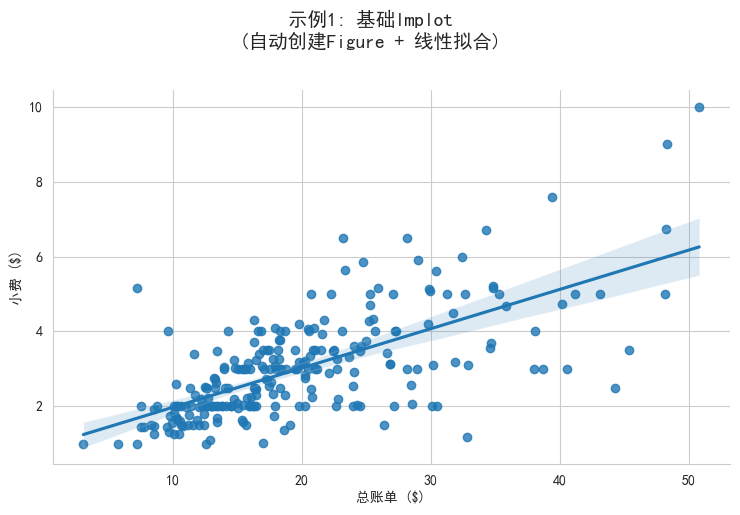


# ========== 示例 2：hue参数 - 按类别分组 ==========


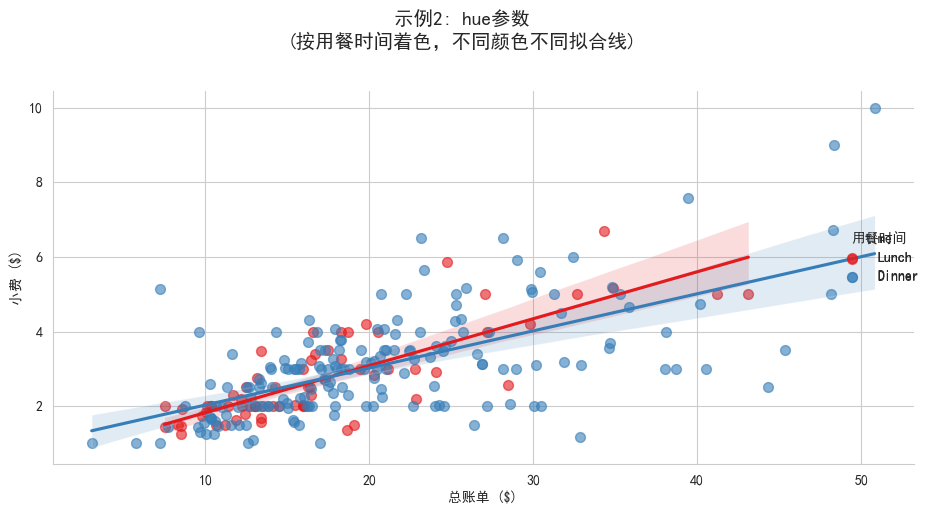


# ========== 示例 3：markers参数 - 不同标记样式 ==========


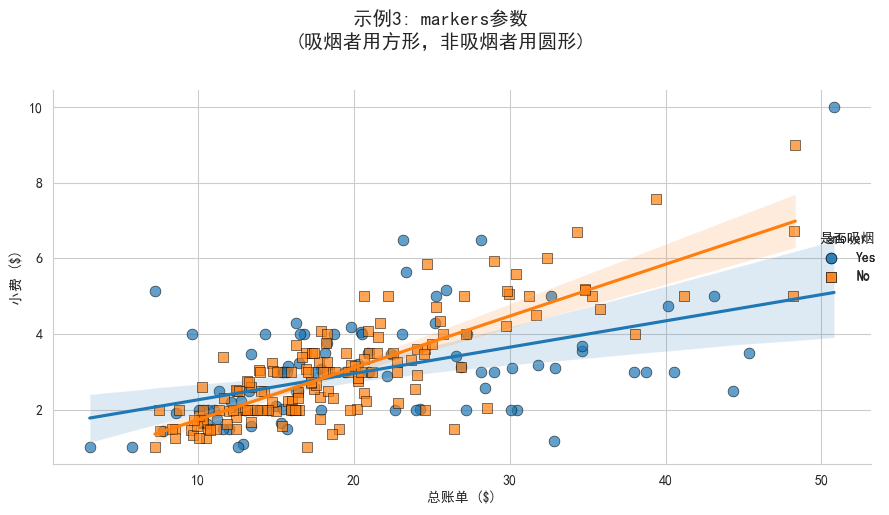


# ========== 示例 4：order参数 - 二次多项式 ==========


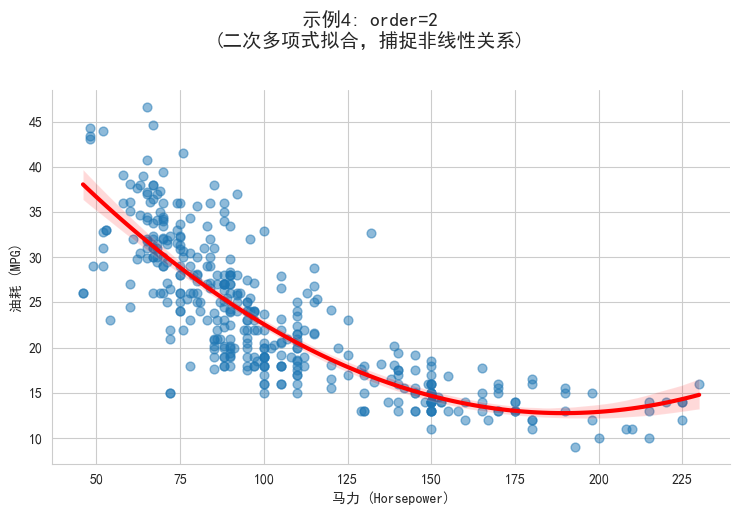


# ========== 示例 5：logistic参数 - S型曲线 ==========


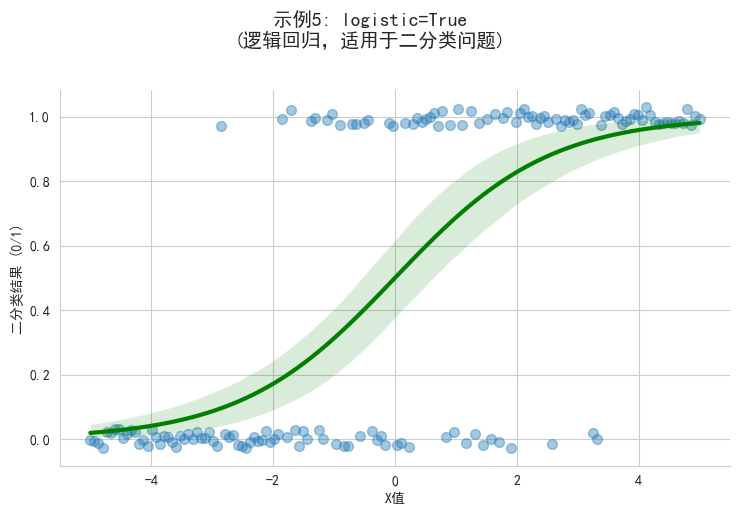

In [6]:
# ==================== 第一部分：基础用法示例 ====================
print("\n" + "=" * 80)  # 打印换行和80个等号，创建分隔线，标记第一部分开始
print("【第一部分】基础用法 - 单图展示")  # 打印部分标题，说明展示lmplot基础用法
print("=" * 80)  # 打印80个等号，结束分隔线

# ========== 示例 1：最基础的 lmplot ==========
print("\n# ========== 示例 1：基础 lmplot ==========")  # 打印示例标题，说明展示基础lmplot
g1 = sns.lmplot(data=tips, x='total_bill', y='tip', height=5,
                aspect=1.5)  # 创建基础lmplot，绘制tips数据集的回归图
# 参数说明：data=tips使用tips数据集，x='total_bill'为x轴（总账单），y='tip'为y轴（小费），height=5设置图高，aspect=1.5设置宽高比
g1.fig.suptitle(
    '示例1: 基础lmplot\n(自动创建Figure + 线性拟合)',  # 设置画布标题，说明基础lmplot功能
    fontsize=14,  # 标题字体大小14，适中醒目
    fontweight='bold',  # 标题粗体，增强视觉效果
    y=1.02)  # 标题位置稍高于画布顶部，避免遮挡
g1.set_axis_labels('总账单 ($)', '小费 ($)')  # 设置x轴标签为“总账单 ($)”，y轴标签为“小费 ($)”
plt.tight_layout()  # 自动调整图表间距，优化布局
plt.show()  # 显示图表，渲染基础lmplot

# ========== 示例 2：hue参数 - 按类别着色 ==========
print("\n# ========== 示例 2：hue参数 - 按类别分组 ==========")  # 打印示例标题，说明hue参数用法
g2 = sns.lmplot(
    data=tips,  # 使用tips数据集绘制lmplot
    x='total_bill',  # x轴使用'total_bill'列（总账单）
    y='tip',  # y轴使用'tip'列（小费）
    hue='time',  # 按'time'列（用餐时间）分组，自动为不同类别分配颜色
    height=5,  # 设置图高为5英寸
    aspect=1.5,  # 设置宽高比为1.5，控制图表比例
    palette='Set1',  # 使用Set1调色板，为不同类别分配鲜明颜色
    scatter_kws={  # 散点参数字典，控制散点样式
        's': 50,  # 设置散点大小为50，适中显示
        'alpha': 0.6  # 设置散点透明度为0.6，增强重叠点可见性
    })
g2.fig.suptitle(
    '示例2: hue参数\n(按用餐时间着色，不同颜色不同拟合线)',  # 设置标题，说明hue分组效果
    fontsize=14,
    fontweight='bold',
    y=1.02)  # 标题字体14，粗体，位置略高
g2.set_axis_labels('总账单 ($)', '小费 ($)')  # 设置x轴和y轴标签
g2.add_legend(title='用餐时间')  # 添加图例，标题为“用餐时间”，显示类别名称
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染hue分组的lmplot

# ========== 示例 3：markers参数 - 不同标记 ==========
print("\n# ========== 示例 3：markers参数 - 不同标记样式 =========="
      )  # 打印示例标题，说明markers参数用法
g3 = sns.lmplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    hue='smoker',  # 按'smoker'列（是否吸烟）分组，分配不同颜色
    markers=['o', 's'],  # 为不同类别设置不同标记：'o'为圆形（非吸烟），'s'为方形（吸烟）
    height=5,  # 设置图高为5英寸
    aspect=1.5,  # 设置宽高比为1.5
    scatter_kws={  # 散点参数字典
        's': 60,  # 设置散点大小为60
        'alpha': 0.7,  # 设置散点透明度为0.7
        'edgecolors': 'black',  # 设置散点边框为黑色，增强对比
        'linewidths': 0.5  # 设置散点边框线宽为0.5，细腻显示
    })
g3.fig.suptitle(
    '示例3: markers参数\n(吸烟者用方形，非吸烟者用圆形)',  # 设置标题，说明markers效果
    fontsize=14,
    fontweight='bold',
    y=1.02)  # 标题字体14，粗体，位置略高
g3.set_axis_labels('总账单 ($)', '小费 ($)')  # 设置x轴和y轴标签
g3.add_legend(title='是否吸烟')  # 添加图例，标题为“是否吸烟”
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染markers分组的lmplot

# ========== 示例 4：order参数 - 多项式回归 ==========
print("\n# ========== 示例 4：order参数 - 二次多项式 ==========")  # 打印示例标题，说明order参数用法
mpg_clean = mpg.dropna(subset=['horsepower',
                               'mpg'])  # 移除mpg数据集中horsepower和mpg列的缺失值，确保数据完整
g4 = sns.lmplot(
    data=mpg_clean,  # 使用清理后的mpg数据集
    x='horsepower',  # x轴使用'horsepower'列（马力）
    y='mpg',  # y轴使用'mpg'列（油耗）
    order=2,  # 设置回归为二次多项式，捕捉非线性关系
    height=5,  # 设置图高为5英寸
    aspect=1.5,  # 设置宽高比为1.5
    scatter_kws={  # 散点参数字典
        's': 40,  # 设置散点大小为40，较小点突出曲线
        'alpha': 0.5  # 设置散点透明度为0.5，平衡显示
    },
    line_kws={  # 回归线参数字典
        'color': 'red',  # 设置回归线颜色为红色，突出曲线
        'linewidth': 3  # 设置回归线宽为3，增强可见性
    })
g4.fig.suptitle(
    '示例4: order=2\n(二次多项式拟合，捕捉非线性关系)',  # 设置标题，说明二次多项式效果
    fontsize=14,
    fontweight='bold',
    y=1.02)  # 标题字体14，粗体，位置略高
g4.set_axis_labels('马力 (Horsepower)', '油耗 (MPG)')  # 设置x轴和y轴标签
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染二次多项式lmplot

# ========== 示例 5：logistic参数 - 逻辑回归 ==========
print("\n# ========== 示例 5：logistic参数 - S型曲线 =========="
      )  # 打印示例标题，说明logistic参数用法
# 创建二分类数据
x_log = np.linspace(-5, 5, 150)  # 生成-5到5的150个均匀分布点，作为x轴值
y_log = (np.random.rand(150) < 1 / (1 + np.exp(-x_log))).astype(
    int)  # 使用sigmoid函数生成0/1二分类y值，模拟逻辑回归数据
logistic_df = pd.DataFrame({'x': x_log, 'y': y_log})  # 创建数据框，存储x和y数据
g5 = sns.lmplot(
    data=logistic_df,  # 使用logistic_df数据集
    x='x',  # x轴使用'x'列，连续值
    y='y',  # y轴使用'y'列，0/1二分类值
    logistic=True,  # 启用逻辑回归，拟合S型曲线
    height=5,  # 设置图高为5英寸
    aspect=1.5,  # 设置宽高比为1.5
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50，适中显示
        'alpha': 0.4  # 设置散点透明度为0.4，突出S型曲线
    },
    line_kws={  # 回归线参数字典
        'color': 'green',  # 设置回归线颜色为绿色，清新风格
        'linewidth': 3  # 设置回归线宽为3，突出S型曲线
    },
    y_jitter=0.03)  # 为y值添加0.03的抖动，避免0/1点重叠
g5.fig.suptitle(
    '示例5: logistic=True\n(逻辑回归，适用于二分类问题)',  # 设置标题，说明逻辑回归效果
    fontsize=14,
    fontweight='bold',
    y=1.02)  # 标题字体14，粗体，位置略高
g5.set_axis_labels('X值', '二分类结果 (0/1)')  # 设置x轴和y轴标签，说明二分类输出
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染逻辑回归lmplot


【第二部分】分面功能 - lmplot 的核心优势

# ========== 示例 6：col参数 - 按列分面 ==========


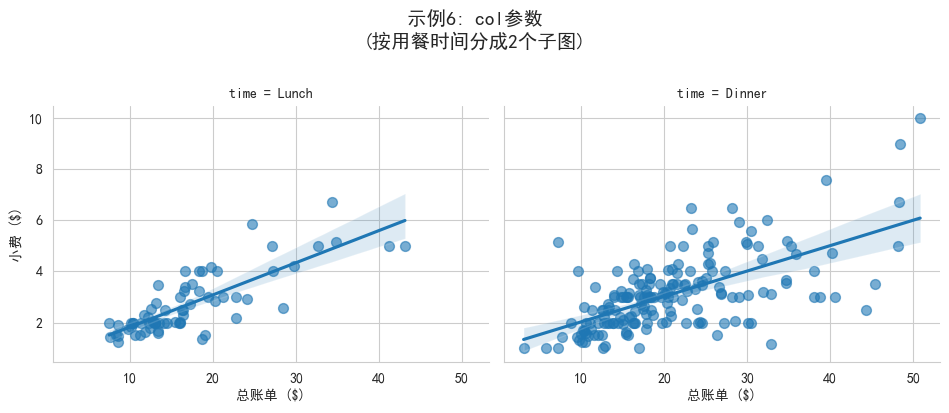


# ========== 示例 7：row参数 - 按行分面 ==========


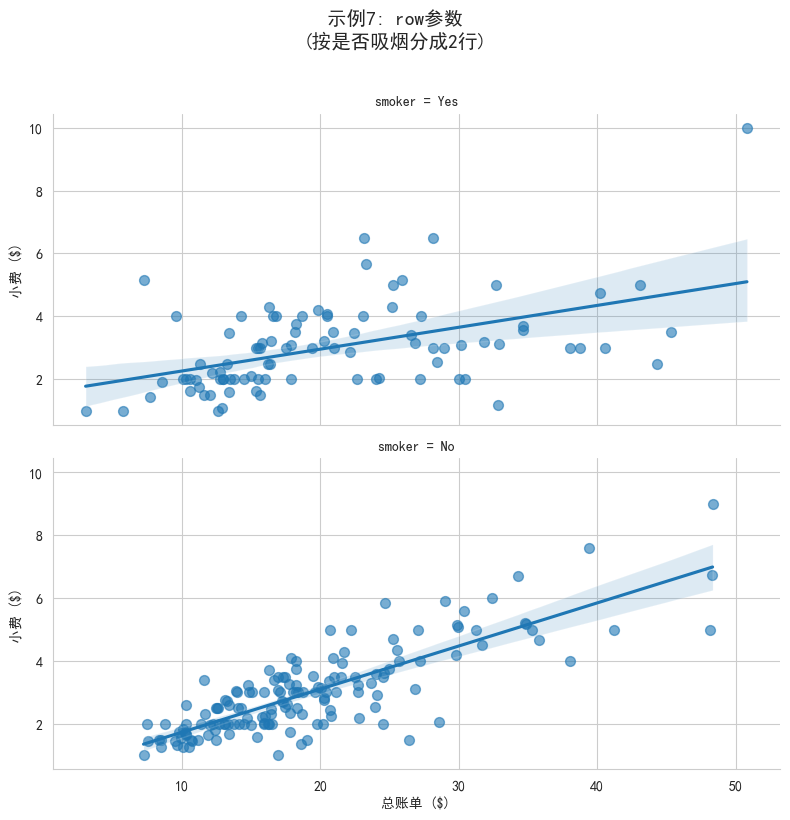


# ========== 示例 8：col + row - 双维度分面 ==========


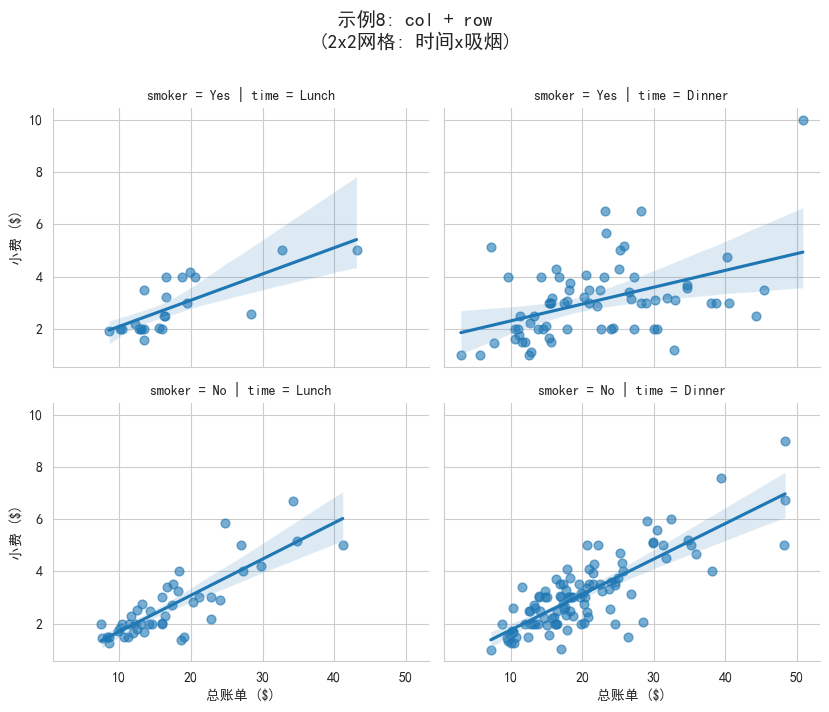


# ========== 示例 9：col + hue - 分面同时着色 ==========


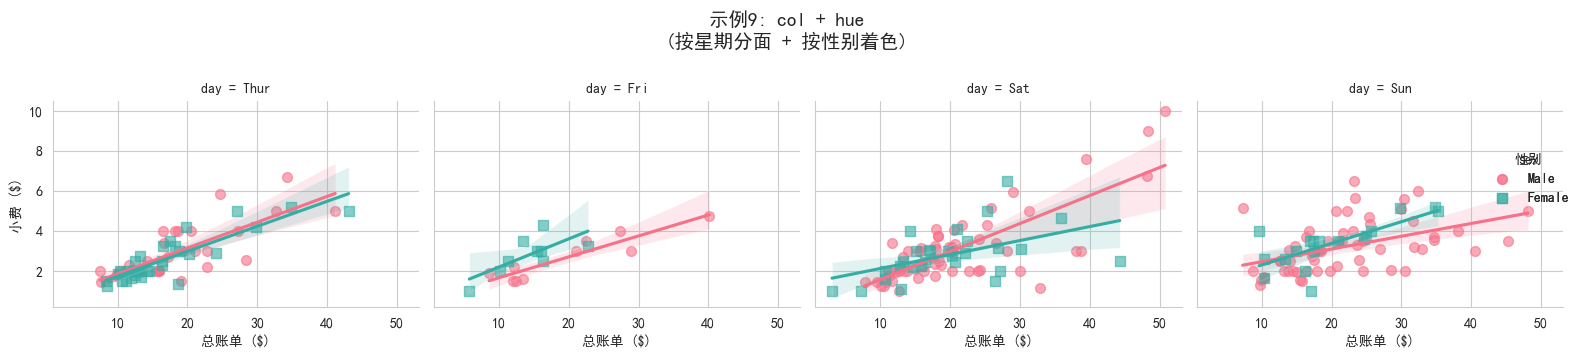


# ========== 示例 10：col_wrap参数 - 自动换行 ==========


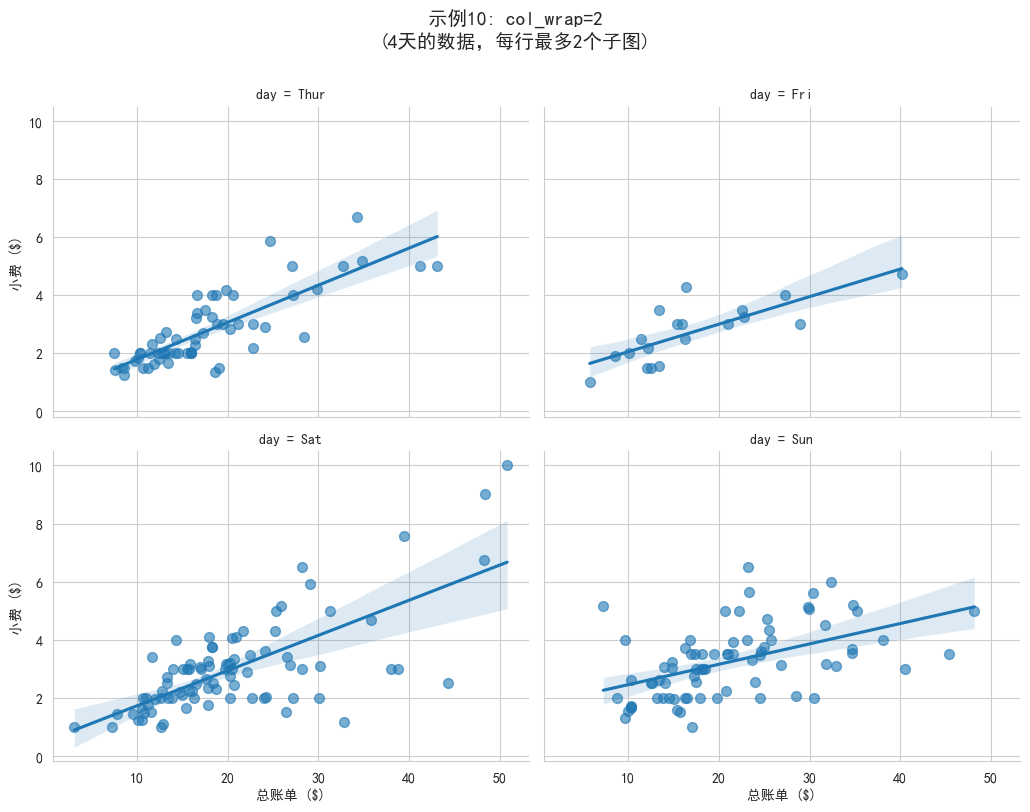


# ========== 示例 11：height + aspect - 图形尺寸控制 ==========


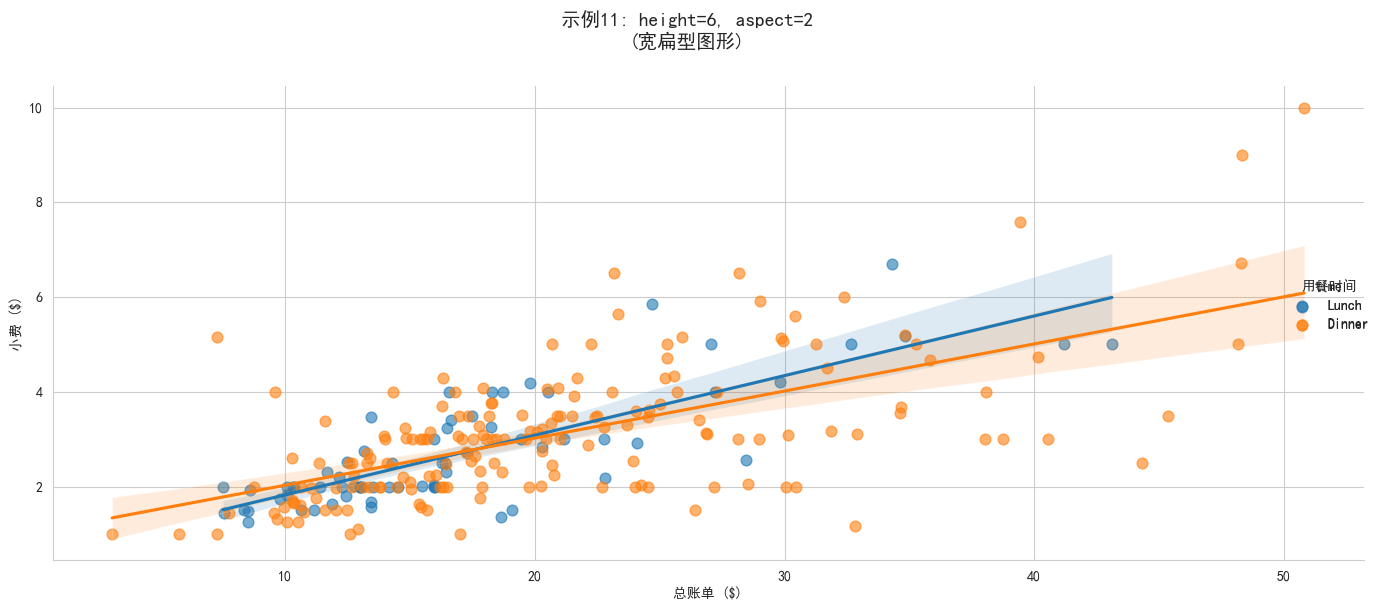


# ========== 示例 12：robust参数 - 抗异常值 ==========


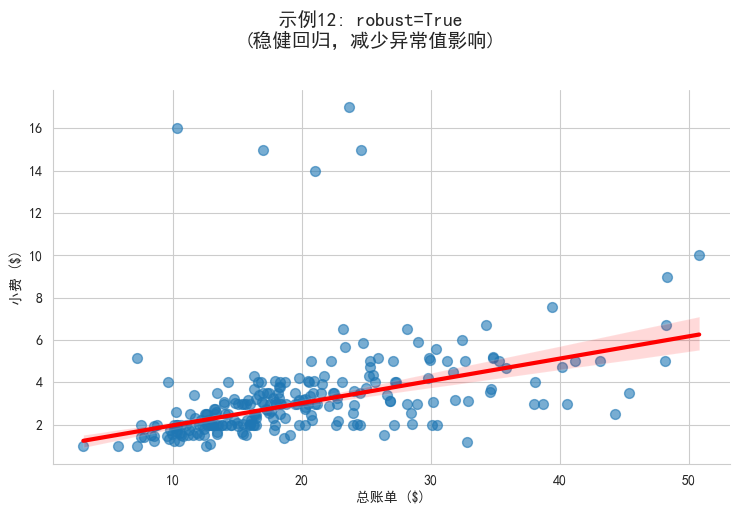


# ========== 示例 13：lowess参数 - 捕捉局部趋势 ==========


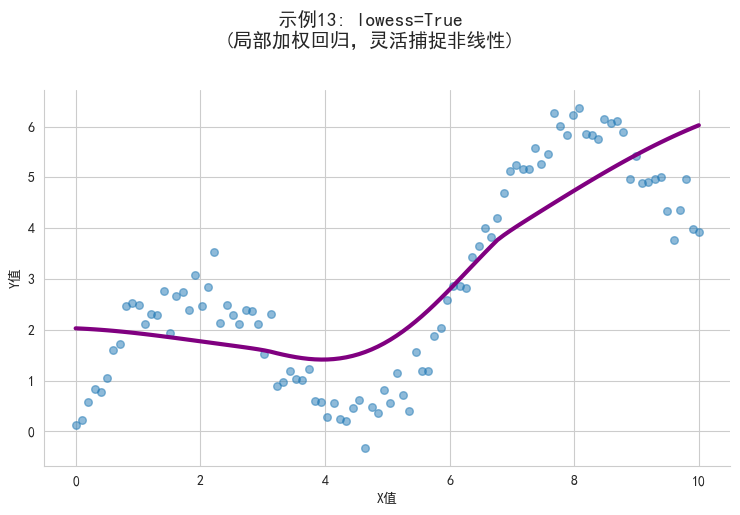


# ========== 示例 14：x_estimator参数 - X值聚合 ==========


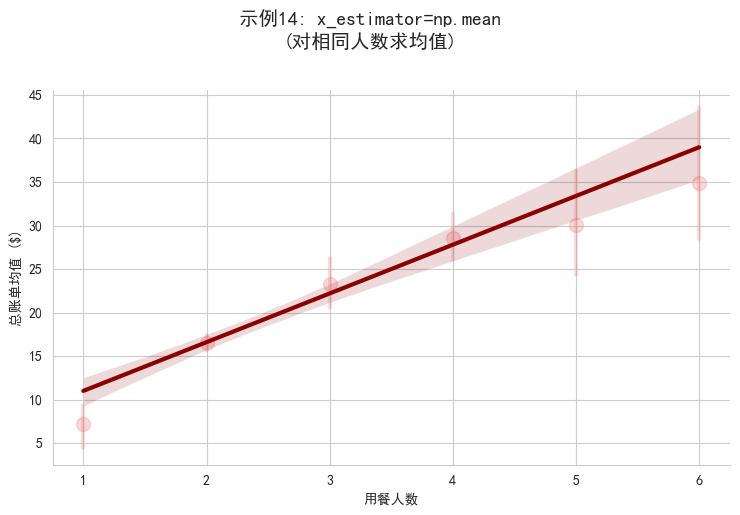


# ========== 示例 15：ci参数 - 不显示置信区间 ==========


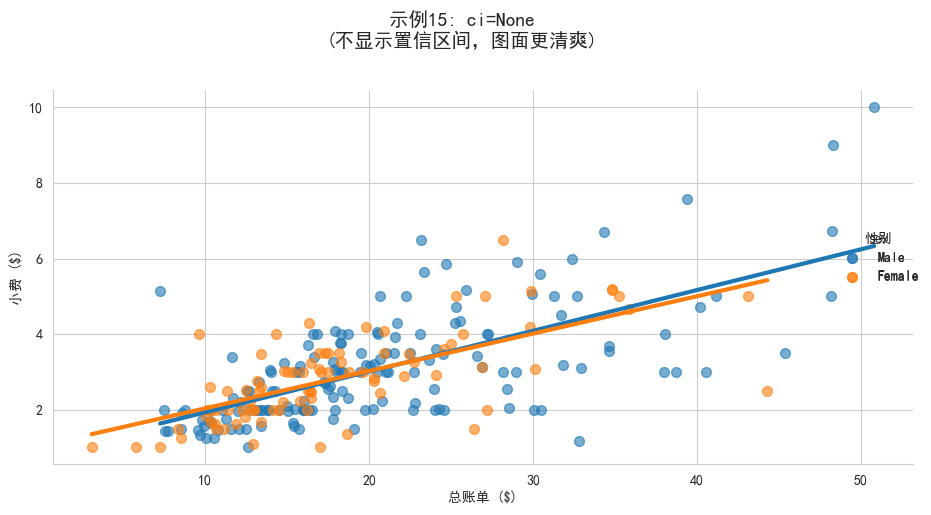


# ========== 示例 16：truncate参数 - 限制回归线 ==========
  (truncate 参数在实际使用中效果明显)

# ========== 示例 17：palette参数 - 美化配色 ==========


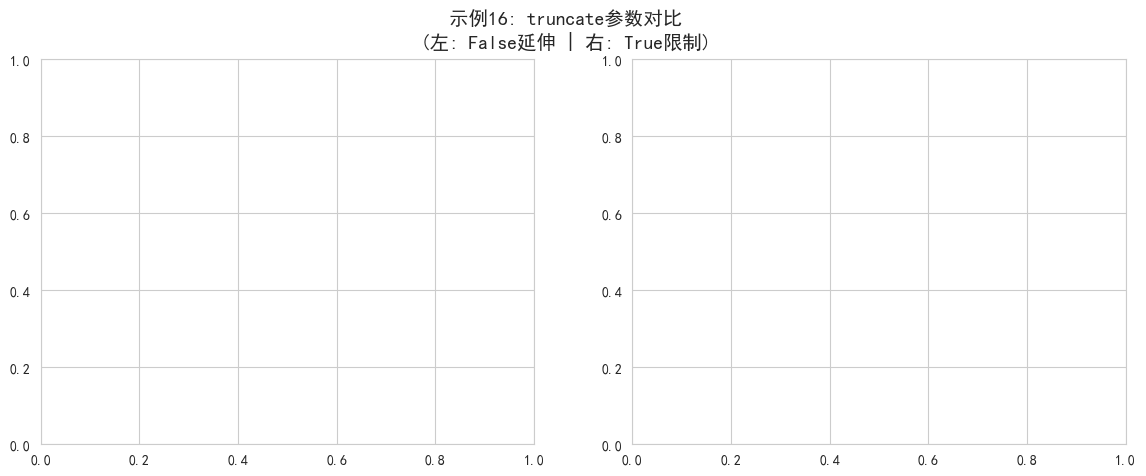

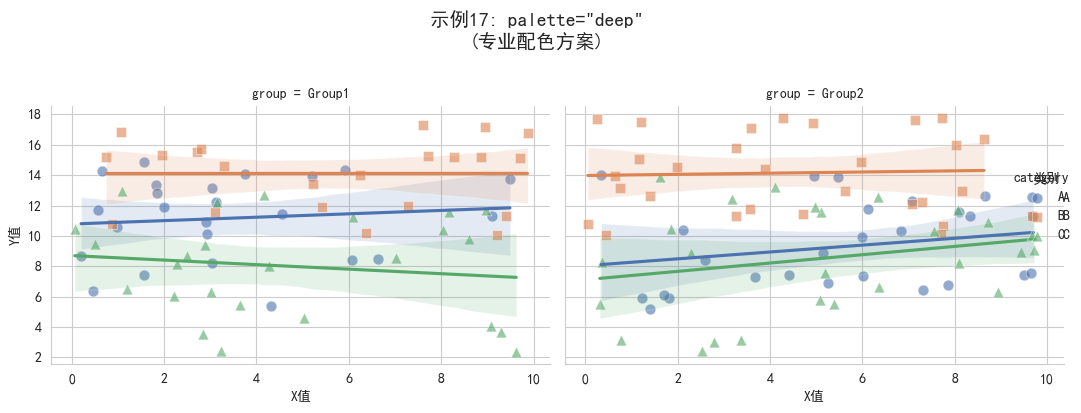

In [7]:
# ==================== 第二部分：分面功能 - lmplot 的核心优势 ====================
print("\n" + "=" * 80)  # 打印换行和80个等号，创建分隔线，标记第二部分开始
print("【第二部分】分面功能 - lmplot 的核心优势")  # 打印部分标题，说明展示lmplot分面功能
print("=" * 80)  # 打印80个等号，结束分隔线

# ========== 示例 6：col参数 - 列分面 ==========
print("\n# ========== 示例 6：col参数 - 按列分面 ==========")  # 打印示例标题，说明col参数用法
g6 = sns.lmplot(
    data=tips,  # 使用tips数据集绘制lmplot
    x='total_bill',  # x轴使用'total_bill'列（总账单）
    y='tip',  # y轴使用'tip'列（小费）
    col='time',  # 按'time'列（用餐时间）分面，生成多列子图
    height=4,  # 设置每个子图高度为4英寸
    aspect=1.2,  # 设置子图宽高比为1.2，适中比例
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50，适中显示
        'alpha': 0.6  # 设置散点透明度为0.6，增强重叠点可见性
    })
g6.fig.suptitle(
    '示例6: col参数\n(按用餐时间分成2个子图)',  # 设置画布标题，说明按时间分面
    fontsize=14,
    fontweight='bold',
    y=1.02)  # 标题字体14，粗体，位置略高
g6.set_axis_labels('总账单 ($)', '小费 ($)')  # 设置x轴和y轴标签
plt.tight_layout()  # 自动调整子图间距，优化布局
plt.show()  # 显示图表，渲染列分面lmplot

# ========== 示例 7：row参数 - 行分面 ==========
print("\n# ========== 示例 7：row参数 - 按行分面 ==========")  # 打印示例标题，说明row参数用法
g7 = sns.lmplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    row='smoker',  # 按'smoker'列（是否吸烟）分面，生成多行子图
    height=4,  # 设置每个子图高度为4英寸
    aspect=2,  # 设置子图宽高比为2，生成较宽子图
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50
        'alpha': 0.6  # 设置散点透明度为0.6
    })
g7.fig.suptitle(
    '示例7: row参数\n(按是否吸烟分成2行)',  # 设置标题，说明按吸烟状态分行
    fontsize=14,
    fontweight='bold',
    y=1.02)  # 标题字体14，粗体，位置略高
g7.set_axis_labels('总账单 ($)', '小费 ($)')  # 设置x轴和y轴标签
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染行分面lmplot

# ========== 示例 8：col + row - 双维度分面 ==========
print("\n# ========== 示例 8：col + row - 双维度分面 ==========")  # 打印示例标题，说明双维度分面
g8 = sns.lmplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    col='time',  # 按'time'列分列，生成多列子图
    row='smoker',  # 按'smoker'列分行，生成多行子图
    height=3.5,  # 设置每个子图高度为3.5英寸，适配多子图
    aspect=1.2,  # 设置子图宽高比为1.2
    scatter_kws={  # 散点参数字典
        's': 40,  # 设置散点大小为40，适合多子图显示
        'alpha': 0.6  # 设置散点透明度为0.6
    })
g8.fig.suptitle(
    '示例8: col + row\n(2x2网格: 时间x吸烟)',  # 设置标题，说明2x2分面网格
    fontsize=14,
    fontweight='bold',
    y=1.01)  # 标题字体14，粗体，位置略高
g8.set_axis_labels('总账单 ($)', '小费 ($)')  # 设置x轴和y轴标签
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染双维度分面lmplot

# ========== 示例 9：col + hue - 分面+着色 ==========
print(
    "\n# ========== 示例 9：col + hue - 分面同时着色 ==========")  # 打印示例标题，说明col和hue组合
g9 = sns.lmplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    col='day',  # 按'day'列（星期）分面，生成多列子图
    hue='sex',  # 按'sex'列（性别）分组，分配不同颜色
    height=3.5,  # 设置每个子图高度为3.5英寸
    aspect=1,  # 设置子图宽高比为1，生成正方形子图
    palette='husl',  # 使用husl调色板，生成柔和且区分度高的颜色
    markers=['o', 's'],  # 为性别设置不同标记：'o'为圆形，'s'为方形
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50
        'alpha': 0.6  # 设置散点透明度为0.6
    })
g9.fig.suptitle(
    '示例9: col + hue\n(按星期分面 + 按性别着色)',  # 设置标题，说明分面和着色效果
    fontsize=14,
    fontweight='bold',
    y=1.01)  # 标题字体14，粗体，位置略高
g9.set_axis_labels('总账单 ($)', '小费 ($)')  # 设置x轴和y轴标签
g9.add_legend(title='性别')  # 添加图例，标题为“性别”，显示性别类别
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染分面+着色lmplot

# ========== 示例 10：col_wrap参数 - 控制列数 ==========
print(
    "\n# ========== 示例 10：col_wrap参数 - 自动换行 ==========")  # 打印示例标题，说明col_wrap参数
g10 = sns.lmplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    col='day',  # 按'day'列分面，生成多列子图
    col_wrap=2,  # 设置每行最多2列子图，自动换行
    height=4,  # 设置每个子图高度为4英寸
    aspect=1.3,  # 设置子图宽高比为1.3
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50
        'alpha': 0.6  # 设置散点透明度为0.6
    })
g10.fig.suptitle(
    '示例10: col_wrap=2\n(4天的数据，每行最多2个子图)',  # 设置标题，说明col_wrap效果
    fontsize=14,
    fontweight='bold',
    y=1.01)  # 标题字体14，粗体，位置略高
g10.set_axis_labels('总账单 ($)', '小费 ($)')  # 设置x轴和y轴标签
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染自动换行分面lmplot

# ========== 示例 11：height + aspect - 控制图形大小 ==========
print("\n# ========== 示例 11：height + aspect - 图形尺寸控制 =========="
      )  # 打印示例标题，说明尺寸控制
g11 = sns.lmplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    hue='time',  # 按'time'列分组，分配不同颜色
    height=6,  # 设置图高为6英寸，生成较大图形
    aspect=2,  # 设置宽高比为2，生成宽扁型图形
    scatter_kws={  # 散点参数字典
        's': 60,  # 设置散点大小为60
        'alpha': 0.6  # 设置散点透明度为0.6
    })
g11.fig.suptitle(
    '示例11: height=6, aspect=2\n(宽扁型图形)',  # 设置标题，说明尺寸控制效果
    fontsize=14,
    fontweight='bold',
    y=1.01)  # 标题字体14，粗体，位置略高
g11.set_axis_labels('总账单 ($)', '小费 ($)')  # 设置x轴和y轴标签
g11.add_legend(title='用餐时间')  # 添加图例，标题为“用餐时间”
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染宽扁型lmplot

# ========== 示例 12：robust参数 - 稳健回归 ==========
print("\n# ========== 示例 12：robust参数 - 抗异常值 ==========")  # 打印示例标题，说明robust参数
# 创建带异常值的数据
outlier_tips = tips.copy()  # 复制tips数据集，避免修改原始数据
outlier_tips.loc[outlier_tips.index[:5], 'tip'] = [15, 16, 14, 17,
                                                   15]  # 前5行tip值设为异常值，模拟异常点
g12 = sns.lmplot(
    data=outlier_tips,  # 使用带异常值的outlier_tips数据集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    robust=True,  # 启用稳健回归，减少异常点影响
    height=5,  # 设置图高为5英寸
    aspect=1.5,  # 设置宽高比为1.5
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50
        'alpha': 0.6  # 设置散点透明度为0.6
    },
    line_kws={  # 回归线参数字典
        'color': 'red',  # 设置回归线颜色为红色，突出线条
        'linewidth': 3  # 设置回归线宽为3，增强可见性
    })
g12.fig.suptitle(
    '示例12: robust=True\n(稳健回归，减少异常值影响)',  # 设置标题，说明稳健回归效果
    fontsize=14,
    fontweight='bold',
    y=1.02)  # 标题字体14，粗体，位置略高
g12.set_axis_labels('总账单 ($)', '小费 ($)')  # 设置x轴和y轴标签
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染稳健回归lmplot

# ========== 示例 13：lowess参数 - 局部加权回归 ==========
print("\n# ========== 示例 13：lowess参数 - 捕捉局部趋势 ==========")  # 打印示例标题，说明lowess参数
# 创建有局部趋势的数据
x_local = np.linspace(0, 10, 100)  # 生成0到10的100个均匀分布点，作为x轴值
y_local = np.sin(x_local) * 2 + x_local * 0.5 + np.random.normal(
    0, 0.3, 100)  # 生成y值：正弦函数+线性趋势+噪声
local_df = pd.DataFrame({'x': x_local, 'y': y_local})  # 创建数据框，存储x和y数据
g13 = sns.lmplot(
    data=local_df,  # 使用local_df数据集
    x='x',  # x轴使用'x'列
    y='y',  # y轴使用'y'列，含局部趋势
    lowess=True,  # 启用局部加权回归（LOWESS），捕捉非线性趋势
    height=5,  # 设置图高为5英寸
    aspect=1.5,  # 设置宽高比为1.5
    scatter_kws={  # 散点参数字典
        's': 30,  # 设置散点大小为30，较小点突出曲线
        'alpha': 0.5  # 设置散点透明度为0.5
    },
    line_kws={  # 回归线参数字典
        'color': 'purple',  # 设置回归线颜色为紫色，突出曲线
        'linewidth': 3  # 设置回归线宽为3，增强可见性
    })
g13.fig.suptitle(
    '示例13: lowess=True\n(局部加权回归，灵活捕捉非线性)',  # 设置标题，说明LOWESS效果
    fontsize=14,
    fontweight='bold',
    y=1.02)  # 标题字体14，粗体，位置略高
g13.set_axis_labels('X值', 'Y值')  # 设置x轴和y轴标签
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染LOWESS回归lmplot

# ========== 示例 14：x_estimator参数 - 数据聚合 ==========
print("\n# ========== 示例 14：x_estimator参数 - X值聚合 =========="
      )  # 打印示例标题，说明x_estimator参数
g14 = sns.lmplot(
    data=tips,  # 使用tips数据集
    x='size',  # x轴使用'size'列（用餐人数，离散值）
    y='total_bill',  # y轴使用'total_bill'列（总账单）
    x_estimator=np.mean,  # 对x的每个唯一值计算y均值，聚合数据
    height=5,  # 设置图高为5英寸
    aspect=1.5,  # 设置宽高比为1.5
    scatter_kws={  # 散点参数字典
        's': 100,  # 设置散点大小为100，突出均值点
        'alpha': 0.3,  # 设置散点透明度为0.3，降低重叠干扰
        'color': 'lightcoral'  # 设置散点颜色为浅珊瑚色，柔和风格
    },
    line_kws={  # 回归线参数字典
        'color': 'darkred',  # 设置回归线颜色为暗红色，突出线条
        'linewidth': 3  # 设置回归线宽为3，增强可见性
    },
    markers='o')  # 设置散点标记为圆形，经典样式
g14.fig.suptitle(
    '示例14: x_estimator=np.mean\n(对相同人数求均值)',  # 设置标题，说明x值聚合效果
    fontsize=14,
    fontweight='bold',
    y=1.02)  # 标题字体14，粗体，位置略高
g14.set_axis_labels('用餐人数', '总账单均值 ($)')  # 设置x轴和y轴标签，说明y轴为均值
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染聚合lmplot

# ========== 示例 15：ci参数 - 置信区间控制 ==========
print("\n# ========== 示例 15：ci参数 - 不显示置信区间 ==========")  # 打印示例标题，说明ci参数
g15 = sns.lmplot(
    data=tips,  # 使用tips数据集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    hue='sex',  # 按'sex'列分组，分配不同颜色
    ci=None,  # 禁用置信区间显示，简化图形
    height=5,  # 设置图高为5英寸
    aspect=1.5,  # 设置宽高比为1.5
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50
        'alpha': 0.6  # 设置散点透明度为0.6
    },
    line_kws={'linewidth': 3})  # 设置回归线宽为3，突出线条
g15.fig.suptitle(
    '示例15: ci=None\n(不显示置信区间，图面更清爽)',  # 设置标题，说明无置信区间效果
    fontsize=14,
    fontweight='bold',
    y=1.02)  # 标题字体14，粗体，位置略高
g15.set_axis_labels('总账单 ($)', '小费 ($)')  # 设置x轴和y轴标签
g15.add_legend(title='性别')  # 添加图例，标题为“性别”
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染无置信区间lmplot

# ========== 示例 16：truncate参数 - 回归线范围 ==========
print("\n# ========== 示例 16：truncate参数 - 限制回归线 =========="
      )  # 打印示例标题，说明truncate参数
fig, axes = plt.subplots(1, 2,
                         figsize=(14, 5))  # 创建1x2子图画布，尺寸14x5英寸，用于对比truncate效果
fig.suptitle(
    '示例16: truncate参数对比\n(左: False延伸 | 右: True限制)',  # 设置画布标题，说明对比效果
    fontsize=14,
    fontweight='bold')  # 标题字体14，粗体
# truncate=False
g16a = sns.lmplot(
    data=tips[tips['total_bill'] > 20],  # 使用total_bill>20的子集，减少数据范围
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    truncate=False,  # 回归线延伸到画布边界
    height=5,  # 设置图高为5英寸
    aspect=1.2,  # 设置宽高比为1.2
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50
        'alpha': 0.6  # 设置散点透明度为0.6
    })
plt.close(g16a.fig)  # 关闭lmplot自动创建的图，避免单独显示
# truncate=True
g16b = sns.lmplot(
    data=tips[tips['total_bill'] > 20],  # 使用相同数据子集
    x='total_bill',  # x轴使用'total_bill'列
    y='tip',  # y轴使用'tip'列
    truncate=True,  # 限制回归线在数据范围内
    height=5,  # 设置图高为5英寸
    aspect=1.2,  # 设置宽高比为1.2
    scatter_kws={  # 散点参数字典
        's': 50,  # 设置散点大小为50
        'alpha': 0.6  # 设置散点透明度为0.6
    })
plt.close(g16b.fig)  # 关闭lmplot自动创建的图
# 由于 lmplot 自动创建图形，这里单独展示
print("  (truncate 参数在实际使用中效果明显)")  # 说明truncate效果需单独查看，因lmplot无法直接画在指定axes

# ========== 示例 17：palette参数 - 调色板 ==========
print("\n# ========== 示例 17：palette参数 - 美化配色 ==========")  # 打印示例标题，说明palette参数
g17 = sns.lmplot(
    data=multi_group,  # 使用multi_group数据集，包含多组数据
    x='x',  # x轴使用'x'列
    y='y',  # y轴使用'y'列
    hue='category',  # 按'category'列（A/B/C）分组，分配不同颜色
    col='group',  # 按'group'列（Group1/Group2）分面，生成多列子图
    height=4,  # 设置每个子图高度为4英寸
    aspect=1.2,  # 设置子图宽高比为1.2
    palette='deep',  # 使用deep调色板，生成专业配色方案
    markers=['o', 's', '^'],  # 为A/B/C类别设置不同标记：圆形、方形、三角形
    scatter_kws={  # 散点参数字典
        's': 60,  # 设置散点大小为60
        'alpha': 0.6,  # 设置散点透明度为0.6
        'edgecolors': 'white',  # 设置散点边框为白色，增强美观
        'linewidths': 0.5  # 设置散点边框线宽为0.5，细腻显示
    })
g17.fig.suptitle(
    '示例17: palette="deep"\n(专业配色方案)',  # 设置标题，说明配色效果
    fontsize=14,
    fontweight='bold',
    y=1.02)  # 标题字体14，粗体，位置略高
g17.set_axis_labels('X值', 'Y值')  # 设置x轴和y轴标签
g17.add_legend(title='类别')  # 添加图例，标题为“类别”
plt.tight_layout()  # 自动调整间距，优化布局
plt.show()  # 显示图表，渲染配色分面lmplot


# ========== 示例 18：综合应用 - 专业级分析 ==========


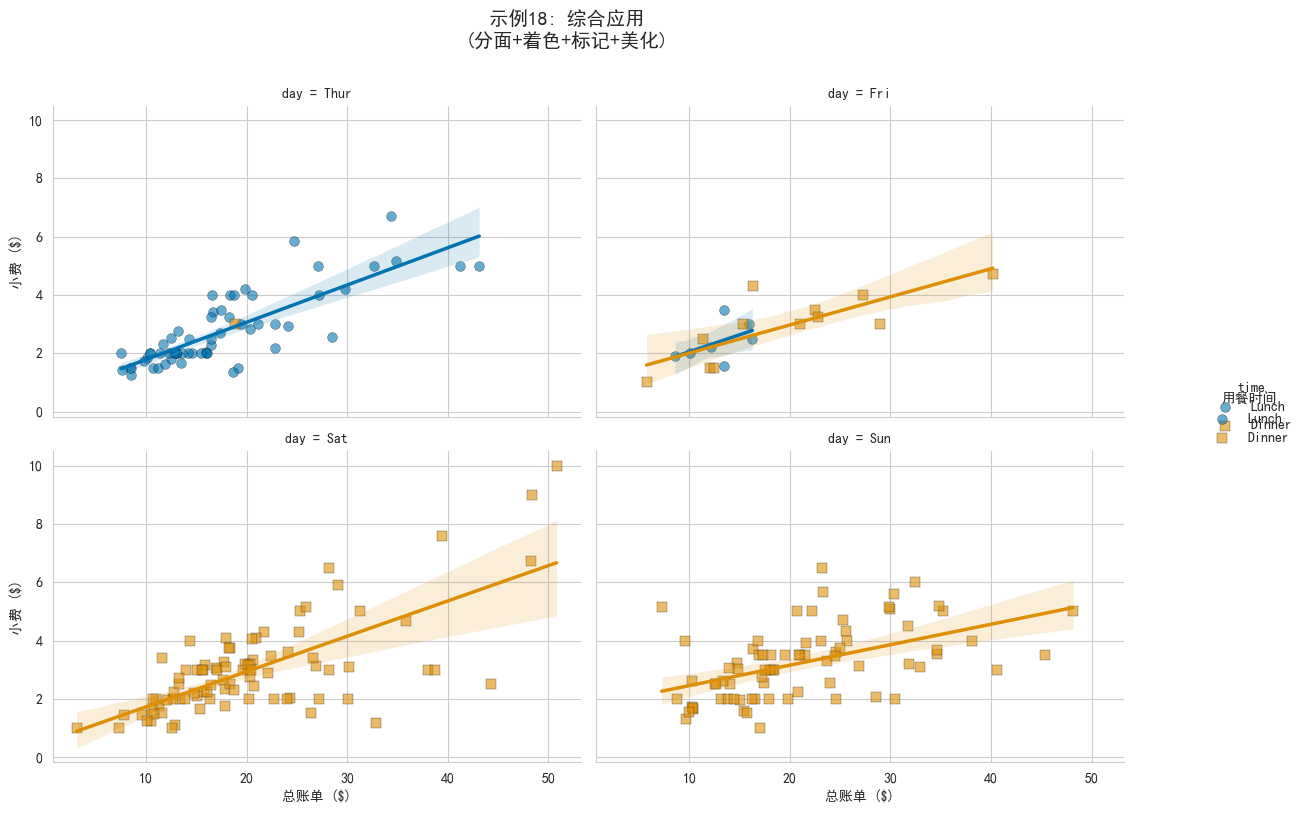

In [8]:
# ========== 示例 18：综合应用 - 完整配置 ==========
print("\n# ========== 示例 18：综合应用 - 专业级分析 ==========")  # 打印示例标题，说明综合应用的完整配置
g18 = sns.lmplot(
    data=tips,  # 使用tips数据集绘制lmplot，展示综合应用
    x='total_bill',  # x轴使用'total_bill'列，表示总账单金额
    y='tip',  # y轴使用'tip'列，表示小费金额
    col='day',  # 按'day'列（星期）分面，生成多列子图
    hue='time',  # 按'time'列（用餐时间）分组，分配不同颜色
    col_wrap=2,  # 设置每行最多2列子图，自动换行显示
    height=4,  # 设置每个子图高度为4英寸，适配多子图
    aspect=1.2,  # 设置子图宽高比为1.2，适中比例
    palette='colorblind',  # 使用colorblind调色板，适合色盲用户，颜色区分度高
    markers=['o', 's'],  # 为用餐时间设置不同标记：'o'为圆形，'s'为方形
    scatter_kws={  # 散点参数字典，精细控制散点样式
        's': 50,  # 设置散点大小为50，适中显示
        'alpha': 0.6,  # 设置散点透明度为0.6，增强重叠点可见性
        'edgecolors': 'black',  # 设置散点边框为黑色，增强对比
        'linewidths': 0.3  # 设置散点边框线宽为0.3，细腻显示
    },
    line_kws={'linewidth': 2.5},  # 设置回归线宽为2.5，突出线条
    ci=95,  # 设置置信区间为95%，显示回归线的可信度
    order=1)  # 设置回归为一次多项式（线性回归）
g18.fig.suptitle(
    '示例18: 综合应用\n(分面+着色+标记+美化)',  # 设置画布标题，说明综合应用效果
    fontsize=14,
    fontweight='bold',
    y=1.01)  # 标题字体14，粗体，位置略高
g18.set_axis_labels('总账单 ($)', '小费 ($)')  # 设置x轴标签为“总账单 ($)”，y轴标签为“小费 ($)”
g18.add_legend(title='用餐时间', bbox_to_anchor=(1.05, 0.5),
               loc='center left')  # 添加图例，标题为“用餐时间”，位于画布右侧中心
plt.tight_layout()  # 自动调整子图间距，优化布局，避免重叠
plt.show()  # 显示图表，渲染综合配置的lmplot

In [9]:
print("\n" + "=" * 80)
print("📊 Seaborn lmplot 教程完成!")
print("=" * 80)
print("\n✅ 核心功能总结:")
print("\n【基础参数】")
print("  • data, x, y - 基础数据")
print("  • hue - 按类别着色")
print("  • markers - 不同标记样式")
print("  • order - 多项式阶数(1/2/3...)")
print("  • logistic - 逻辑回归")
print("  • lowess - 局部加权回归")
print("  • robust - 稳健回归")
print("\n【分面参数 - lmplot 核心优势】")
print("  • col - 按列分面")
print("  • row - 按行分面")
print("  • col_wrap - 控制每行列数")
print("  • height - 每个子图高度")
print("  • aspect - 宽高比")
print("\n【美化参数】")
print("  • palette - 调色板")
print("  • scatter_kws - 散点样式")
print("  • line_kws - 回归线样式")
print("  • ci - 置信区间(68/95/None)")
print("  • truncate - 回归线范围")
print("  • x_estimator - X值聚合")
print("\n" + "=" * 80)
print("💡 lmplot vs regplot 对比:")
print("  【lmplot】图级函数 - 适合需要分面的复杂分析")
print("    ✓ 自动创建 Figure")
print("    ✓ 支持 col/row 分面")
print("    ✓ 返回 FacetGrid 对象")
print("    ✗ 不能画在指定 ax 上")
print("\n  【regplot】轴级函数 - 适合嵌入到已有图形")
print("    ✓ 可以画在指定 ax 上")
print("    ✓ 灵活组合多个子图")
print("    ✗ 不支持自动分面")
print("    ✗ 需要手动创建 Figure")
print("=" * 80)
print("\n🎯 选择建议:")
print("  • 需要按类别分面 → 用 lmplot")
print("  • 需要精确控制布局 → 用 regplot")
print("  • 快速探索性分析 → 用 lmplot")
print("  • 嵌入复杂图形 → 用 regplot")
print("=" * 80)


📊 Seaborn lmplot 教程完成!

✅ 核心功能总结:

【基础参数】
  • data, x, y - 基础数据
  • hue - 按类别着色
  • markers - 不同标记样式
  • order - 多项式阶数(1/2/3...)
  • logistic - 逻辑回归
  • lowess - 局部加权回归
  • robust - 稳健回归

【分面参数 - lmplot 核心优势】
  • col - 按列分面
  • row - 按行分面
  • col_wrap - 控制每行列数
  • height - 每个子图高度
  • aspect - 宽高比

【美化参数】
  • palette - 调色板
  • scatter_kws - 散点样式
  • line_kws - 回归线样式
  • ci - 置信区间(68/95/None)
  • truncate - 回归线范围
  • x_estimator - X值聚合

💡 lmplot vs regplot 对比:
  【lmplot】图级函数 - 适合需要分面的复杂分析
    ✓ 自动创建 Figure
    ✓ 支持 col/row 分面
    ✓ 返回 FacetGrid 对象
    ✗ 不能画在指定 ax 上

  【regplot】轴级函数 - 适合嵌入到已有图形
    ✓ 可以画在指定 ax 上
    ✓ 灵活组合多个子图
    ✗ 不支持自动分面
    ✗ 需要手动创建 Figure

🎯 选择建议:
  • 需要按类别分面 → 用 lmplot
  • 需要精确控制布局 → 用 regplot
  • 快速探索性分析 → 用 lmplot
  • 嵌入复杂图形 → 用 regplot
